# Simple Pair Backtest

A minimal notebook to backtest any two-ETF pair with periodic rebalancing.

## What this does
- Supports long/short direction per leg
- Rebalances both legs once per chosen period
- Sizes notionals to hit a target net beta exposure (default: beta-neutral)
- Tracks equity curve, drawdown, and simple performance stats

## Starter pair
- Leg A: `APLX` (short)
- Leg B: `APLZ` (short)
- Target: net beta exposure = 0


In [1]:
import io
import time
import ftplib
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yfple
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
# --- Parameters ---
# Auto-select all bucket-3 inverse ETFs with negative beta from latest screener.
UNIVERSE_SOURCE_CSV = "../data/etf_screened_today.csv"

# Keep these for plotting cell compatibility; they will be set from first pair run.

START = "2022-03-31"
END = None

# Direction: +1 = long, -1 = short
# Requested setup: short inverse ETF and short underlying.
LEG_A_SIDE = -1
LEG_B_SIDE = -1

# Beta to underlying (or benchmark beta exposure) for each leg
# Used as manual fallback if auto lookup does not find a value.
# Inverse ETF leg defaults to -2x; underlying leg defaults to +1x.
LEG_A_BETA = -2.0
LEG_B_BETA = 1.0
USE_BETA_FROM_SCREENED = True
BETA_SOURCE_CSV = UNIVERSE_SOURCE_CSV

INITIAL_CAPITAL = 100_000
TARGET_GROSS_MULTIPLIER = 1.0   # gross notional as multiple of equity
TARGET_NET_BETA_NOTIONAL = 0.0  # 0 = beta-neutral

# Borrow settings (applies daily carry on short legs)
USE_BORROW_FROM_SCREENED = True
# ETF borrow: average fee-only borrow across all historical screener snapshots.
BORROW_SOURCE_GLOBS = [
    "../data/etf_screened_today.csv",
    "../data/runs/*/etf_screened_today.csv",
    "../../etf-dashboard/data/etf_screened_today.csv",
    "../../etf-dashboard/data/runs/*/etf_screened_today.csv",
]
# Underlying borrow: IBKR FTP snapshot (same method used in daily_screener.py).
USE_IBKR_FTP_FOR_UNDERLYINGS = True
FTP_HOST = "ftp2.interactivebrokers.com"
FTP_USER = "shortstock"
FTP_PASS = ""
FTP_FILE = "usa.txt"
FTP_MAX_RETRIES = 3
IBKR_BORROW_CACHE_PATH = Path("../data/borrow_cache.csv")

BORROW_FALLBACK_ANNUAL = 0.1
MANUAL_BORROW_OVERRIDE = {
    # "APLZ": 0.12,
    # "AMZN": 0.01,
}

# Bucket 4 internalization assumption: no external underlying borrow cost.
UNDERLYING_INTERNALIZED_BORROW_ANNUAL = 0.0

# Bucket 4 internalization assumption: no short-sale proceeds credit.
SHORT_PROCEEDS_ANNUAL = 0.0

# Rebalance cadence comparison set.
REBALANCE_FREQ_MAP = {
    "bi_weekly": "2W-FRI",
}
# Default used by the existing plot cell after the comparison run.
REBALANCE_FREQ = "bi-weekly"

# Per-trade cost in bps applied to gross notional traded
FEE_BPS = 0.0

# When Yahoo is unreachable: load `{TICKER}.csv` (Date index, `close` column) from these dirs (first match wins).
# Share `../data/price_cache_v6/` with scripts/bucket4_v6_hedge_backtest.py or drop exports from another machine.
PRICE_CACHE_DIRS = [
    Path("../data/notebook_price_cache"),
    Path("../data/price_cache_v6"),
]

In [3]:
def _extract_close_series(raw: pd.DataFrame, ticker: str) -> pd.Series:
    """Return a 1D Close series across yfinance output shapes."""
    if raw is None or len(raw) == 0:
        return pd.Series(dtype=float, name=ticker)

    close = None
    if isinstance(raw.columns, pd.MultiIndex):
        # Common patterns:
        # - level0 has OHLC fields and level1 has ticker
        # - level0 has ticker and level1 has OHLC fields
        lvl0 = [str(x).lower() for x in raw.columns.get_level_values(0)]
        lvl1 = [str(x).lower() for x in raw.columns.get_level_values(1)]

        if "close" in lvl0:
            close = raw.xs("Close", axis=1, level=0)
        elif "close" in lvl1:
            close = raw.xs("Close", axis=1, level=1)
    else:
        if "Close" in raw.columns:
            close = raw["Close"]

    if close is None:
        raise RuntimeError(f"Missing Close column for {ticker}")

    # Ensure 1D output even if close came back as a 2D frame.
    if isinstance(close, pd.DataFrame):
        if close.shape[1] == 0:
            raise RuntimeError(f"Empty Close data for {ticker}")
        if ticker in close.columns:
            s = close[ticker]
        elif str(ticker).upper() in [str(c).upper() for c in close.columns]:
            pick = next(c for c in close.columns if str(c).upper() == str(ticker).upper())
            s = close[pick]
        else:
            s = close.iloc[:, 0]
    else:
        s = close

    return pd.to_numeric(s, errors="coerce").rename(ticker)


def _read_close_from_csv_cache(ticker: str, start: str, end: str | None) -> pd.Series | None:
    """Optional offline prices: one CSV per ticker, index=date, column close (case-insensitive)."""
    for base in PRICE_CACHE_DIRS:
        p = base / f"{ticker}.csv"
        if not p.is_file():
            continue
        df = pd.read_csv(p, index_col=0, parse_dates=True)
        cols = {str(c).lower(): c for c in df.columns}
        col = cols.get("close", df.columns[0] if len(df.columns) == 1 else None)
        if col is None:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        s.index = pd.to_datetime(s.index).tz_localize(None)
        s = s.sort_index().loc[s.index >= pd.Timestamp(start)]
        if end:
            s = s.loc[: pd.Timestamp(end)]
        if len(s) > 0:
            print(f"[CACHE] {ticker} <- {p}")
            return s.rename(ticker)
    return None


def _download_close_series(ticker: str, start: str, end: str | None, *, retries: int = 3) -> pd.Series:
    last_err: Exception | None = None
    for attempt in range(retries):
        try:
            tkr = yf.Ticker(ticker)
            df = tkr.history(start=start, end=end, auto_adjust=True, repair=True)
            if df is not None and len(df) > 0 and "Close" in df.columns:
                s = df["Close"].dropna()
                s.index = pd.to_datetime(s.index).tz_localize(None)
                return s.rename(ticker)
        except Exception as e:
            last_err = e
        try:
            kwargs = dict(start=start, end=end, auto_adjust=True, progress=False)
            try:
                raw = yf.download(ticker, **kwargs, timeout=90)
            except TypeError:
                raw = yf.download(ticker, **kwargs)
            s = _extract_close_series(raw, ticker)
            if len(s.dropna()) > 0:
                return s
        except Exception as e:
            last_err = e
        time.sleep(0.5 * (attempt + 1))
    hint = ", ".join(str(d) for d in PRICE_CACHE_DIRS)
    err = RuntimeError(
        f"No Yahoo/cache price data for {ticker} (last error: {last_err}). "
        f"Add {ticker}.csv under one of: {hint}"
    )
    if last_err:
        raise err from last_err
    raise err


def _load_leg_close(ticker: str, start: str, end: str | None) -> pd.Series:
    c = _read_close_from_csv_cache(ticker, start, end)
    if c is not None:
        return c
    return _download_close_series(ticker, start, end)


def load_prices(leg_a_ticker: str, leg_b_ticker: str, start: str, end: str | None = None) -> pd.DataFrame:
    # Pull each leg independently so we can explicitly align to the later
    # first-valid date (true common-live window for decay calculations).
    a = _load_leg_close(leg_a_ticker, start, end).rename("a_px")
    b = _load_leg_close(leg_b_ticker, start, end).rename("b_px")

    first_a = a.dropna().index.min()
    first_b = b.dropna().index.min()
    if pd.isna(first_a) or pd.isna(first_b):
        raise RuntimeError(f"No valid price history for selected pair: {leg_a_ticker}/{leg_b_ticker}")

    aligned_start = max(first_a, first_b)
    if aligned_start > pd.Timestamp(start):
        print(
            f"[PAIR START] {leg_a_ticker}/{leg_b_ticker} aligned start moved "
            f"from {pd.Timestamp(start).date()} to {aligned_start.date()}"
        )

    px = pd.concat([a, b], axis=1)
    px = px.loc[px.index >= aligned_start].dropna()
    if px.empty:
        raise RuntimeError("No overlapping price data for selected pair after start alignment.")
    return px


def _norm_sym(x: str) -> str:
    return str(x).strip().upper()


def _pick_borrow_fee_only(row: pd.Series) -> float | None:
    # Match dashboard behavior: prefer fee-only borrow fields.
    for key in ("borrow_current", "borrow_fee_annual", "borrow_net_annual"):
        if key not in row.index:
            continue
        v = row.get(key)
        if pd.isna(v):
            continue
        try:
            return float(v)
        except Exception:
            continue
    return None


def _collect_screened_csv_paths(glob_patterns: list[str] | str) -> list[str]:
    patterns = [glob_patterns] if isinstance(glob_patterns, str) else list(glob_patterns)
    out: list[str] = []
    seen: set[str] = set()

    for pattern in patterns:
        if not pattern:
            continue
        for p in Path().glob(pattern):
            if not p.is_file():
                continue
            rp = str(p.resolve())
            if rp in seen:
                continue
            seen.add(rp)
            out.append(rp)

    out.sort()
    return out


def load_bucket3_pairs(screened_csv: str) -> list[tuple[str, str]]:
    df = pd.read_csv(screened_csv)
    cols = {c.lower(): c for c in df.columns}
    etf_col = cols.get("etf")
    und_col = cols.get("underlying")
    bucket_col = cols.get("bucket")
    beta_col = cols.get("beta")

    required = {"etf": etf_col, "underlying": und_col, "beta": beta_col}
    missing = [k for k, v in required.items() if v is None]
    if missing:
        raise ValueError(f"Missing required columns in {screened_csv}: {missing}")

    if bucket_col:
        tmp = df[[etf_col, und_col, bucket_col, beta_col]].copy()
    else:
        # Some snapshots only include screened rows with no explicit bucket column.
        tmp = df[[etf_col, und_col, beta_col]].copy()

    tmp[etf_col] = tmp[etf_col].astype(str).map(_norm_sym)
    tmp[und_col] = tmp[und_col].astype(str).map(_norm_sym)
    tmp[beta_col] = pd.to_numeric(tmp[beta_col], errors="coerce")

    m = tmp[beta_col].notna() & (tmp[beta_col] < 0) & tmp[etf_col].ne("") & tmp[und_col].ne("")
    if bucket_col:
        m = m & tmp[bucket_col].astype(str).str.lower().eq("bucket_3_inverse")

    sel = tmp.loc[m, [etf_col, und_col]].drop_duplicates()
    pairs = [(r[etf_col], r[und_col]) for _, r in sel.iterrows()]
    if not pairs:
        raise RuntimeError("No inverse negative-beta pairs found in screener.")
    return pairs


def _parse_ftp_text(text: str) -> pd.DataFrame:
    lines = [ln for ln in text.splitlines() if ln.strip()]
    header_idx = next((i for i, ln in enumerate(lines) if ln.startswith("#SYM|")), None)
    if header_idx is None:
        raise ValueError("Could not find header line '#SYM|'")
    header_cols = [c.strip().lstrip("#").lower() for c in lines[header_idx].split("|")]
    data_lines = lines[header_idx + 1 :]
    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="|", header=None, engine="python")
    df = df.iloc[:, : min(len(header_cols), df.shape[1])]
    df.columns = header_cols[: df.shape[1]]
    return df.drop(columns=[c for c in df.columns if not c or str(c).startswith("unnamed")], errors="ignore")


def fetch_ibkr_shortstock_file(
    filename: str = FTP_FILE,
    max_retries: int = FTP_MAX_RETRIES,
    cache_path: Path = IBKR_BORROW_CACHE_PATH,
) -> pd.DataFrame:
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            print(f"[FTP] Connecting to {FTP_HOST} ... (attempt {attempt}/{max_retries})")
            ftp = ftplib.FTP(timeout=30)
            try:
                ftp.connect(FTP_HOST, 21)
                ftp.login(user=FTP_USER, passwd=FTP_PASS)
                ftp.set_pasv(True)
                buf = io.BytesIO()
                ftp.retrbinary(f"RETR {filename}", buf.write)
            finally:
                try:
                    ftp.quit()
                except Exception:
                    try:
                        ftp.close()
                    except Exception:
                        pass

            text = buf.getvalue().decode("utf-8", errors="ignore")
            df = _parse_ftp_text(text)
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            df.to_csv(cache_path, index=False)
            print(f"[FTP] Parsed {len(df)} rows (cached to {cache_path})")
            return df
        except Exception as e:
            last_err = e
            if attempt < max_retries:
                time.sleep(2 ** attempt)

    if cache_path.exists():
        print(f"[FTP] All retries failed. Falling back to cache: {cache_path}")
        return pd.read_csv(cache_path)
    raise ConnectionError(f"IBKR FTP unavailable and no cache present. Last error: {last_err}")


def _parse_rate_to_decimal(x) -> float:
    if x is None:
        return np.nan
    s = str(x).strip()
    if s == "" or s.upper() in {"N/A", "NA", "NONE", "NULL"}:
        return np.nan
    s = s.replace("%", "").strip()
    try:
        return float(s) / 100.0
    except Exception:
        return np.nan


def get_ibkr_borrow_map(symbols: list[str]) -> dict[str, float]:
    symbols = list(dict.fromkeys([_norm_sym(s) for s in symbols if str(s).strip()]))
    if not symbols:
        return {}

    short_df = fetch_ibkr_shortstock_file(FTP_FILE)
    for req in ("sym", "feerate"):
        if req not in short_df.columns:
            raise ValueError(f"Expected '{req}' column; got: {list(short_df.columns)}")

    df = short_df.copy()
    df["sym"] = df["sym"].astype(str).str.upper().str.strip()
    df["borrow_fee_annual"] = df["feerate"].map(_parse_rate_to_decimal)

    agg = (
        df.groupby("sym", as_index=False)
        .agg(borrow_fee_annual=("borrow_fee_annual", "max"))
        .dropna(subset=["borrow_fee_annual"])
    )
    return {str(r["sym"]): float(r["borrow_fee_annual"]) for _, r in agg.iterrows() if str(r["sym"]) in symbols}


def load_pair_borrow_rates(
    ticker_a: str,
    ticker_b: str,
    screened_csv_globs: list[str] | str,
    use_screened: bool,
    fallback_annual: float,
    underlying_ibkr_map: dict[str, float] | None = None,
    manual_override: dict[str, float] | None = None,
) -> tuple[float, float]:
    ticker_a = _norm_sym(ticker_a)
    ticker_b = _norm_sym(ticker_b)
    rates = {ticker_a: float(fallback_annual), ticker_b: float(fallback_annual)}

    # ETF leg: use historical average from screener snapshots.
    if use_screened:
        vals_a: list[float] = []
        for path in _collect_screened_csv_paths(screened_csv_globs):
            try:
                df = pd.read_csv(path)
            except Exception:
                continue
            if "ETF" not in df.columns:
                continue
            df["ETF"] = df["ETF"].astype(str).str.upper().str.strip()
            for _, row in df.iterrows():
                if str(row.get("ETF", "")).upper().strip() != ticker_a:
                    continue
                borrow = _pick_borrow_fee_only(row)
                if borrow is not None and np.isfinite(borrow):
                    vals_a.append(float(borrow))
        if vals_a:
            rates[ticker_a] = float(np.mean(vals_a))

    # Underlying leg: use IBKR FTP map (daily_screener method).
    if underlying_ibkr_map is not None and ticker_b in underlying_ibkr_map and np.isfinite(underlying_ibkr_map[ticker_b]):
        rates[ticker_b] = float(underlying_ibkr_map[ticker_b])

    if manual_override:
        for k, v in manual_override.items():
            rates[_norm_sym(k)] = float(v)

    return rates[ticker_a], rates[ticker_b]


def load_beta_values(
    ticker_a: str,
    ticker_b: str,
    screened_csv: str,
    use_screened: bool,
    fallback_a: float,
    fallback_b: float,
) -> tuple[float, float]:
    beta_map = {_norm_sym(ticker_a): float(fallback_a), _norm_sym(ticker_b): float(fallback_b)}

    if use_screened:
        try:
            df = pd.read_csv(screened_csv)
            cols_lower = {c.lower(): c for c in df.columns}
            etf_col = cols_lower.get("etf")
            beta_col = cols_lower.get("beta")
            if etf_col and beta_col:
                df[etf_col] = df[etf_col].astype(str).str.upper().str.strip()
                tmp = df[[etf_col, beta_col]].dropna()
                for _, r in tmp.iterrows():
                    etf = str(r[etf_col])
                    if etf in beta_map:
                        beta_map[etf] = float(r[beta_col])
        except Exception as e:
            print(f"[WARN] Could not load betas from {screened_csv}: {e}")

    return beta_map[_norm_sym(ticker_a)], beta_map[_norm_sym(ticker_b)]


def solve_beta_hedged_notionals(
    gross_notional: float,
    side_a: float,
    side_b: float,
    beta_a: float,
    beta_b: float,
    target_net_beta_notional: float = 0.0,
) -> tuple[float, float]:
    a = float(side_a) * float(beta_a)
    b = float(side_b) * float(beta_b)
    g = float(gross_notional)
    t = float(target_net_beta_notional)

    denom = a - b
    if abs(denom) < 1e-12:
        n_a = 0.5 * g
        n_b = 0.5 * g
    else:
        n_a = (t - b * g) / denom
        n_b = g - n_a

    n_a = max(0.0, n_a)
    n_b = max(0.0, n_b)
    s = n_a + n_b
    if s <= 0:
        return 0.5 * g, 0.5 * g
    return g * n_a / s, g * n_b / s


def run_pair_backtest(
    prices: pd.DataFrame,
    rebal_freq: str = "W-FRI",
    initial_capital: float = 100_000,
    gross_multiplier: float = 1.0,
    side_a: float = -1.0,
    side_b: float = -1.0,
    beta_a: float = 2.0,
    beta_b: float = -2.0,
    target_net_beta_notional: float = 0.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    short_proceeds_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    bt["rebalance"] = False

    rf = str(rebal_freq).upper().strip()
    if rf == "TWICE_WEEKLY":
        rebalance_dates = bt.resample("W-TUE").last().index.union(bt.resample("W-FRI").last().index)
    elif rf in REBALANCE_FREQ_MAP and REBALANCE_FREQ_MAP[rf].upper() != "TWICE_WEEKLY":
        rebalance_dates = bt.resample(REBALANCE_FREQ_MAP[rf]).last().index
    else:
        rebalance_dates = bt.resample(rebal_freq).last().index

    bt.loc[bt.index.isin(rebalance_dates), "rebalance"] = True
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh = 0.0
    b_sh = 0.0
    cash = float(initial_capital)

    rows = []
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0
    short_proceeds_daily = float(short_proceeds_annual) / 252.0

    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])

        a_pos_notional = a_sh * ap
        b_pos_notional = b_sh * bp

        borrow_cost = 0.0
        short_proceeds_credit = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
            short_proceeds_credit += abs(a_pos_notional) * short_proceeds_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
            short_proceeds_credit += abs(b_pos_notional) * short_proceeds_daily

        financing_pnl = short_proceeds_credit - borrow_cost
        cash += financing_pnl

        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            n_a, n_b = solve_beta_hedged_notionals(
                gross_notional=target_gross,
                side_a=side_a,
                side_b=side_b,
                beta_a=beta_a,
                beta_b=beta_b,
                target_net_beta_notional=target_net_beta_notional,
            )

            target_a_pos = float(side_a) * n_a
            target_b_pos = float(side_b) * n_b

            delta_a = target_a_pos - a_pos_notional
            delta_b = target_b_pos - b_pos_notional

            traded_gross = abs(delta_a) + abs(delta_b)
            fee = traded_gross * fee_rate

            cash -= delta_a
            cash -= delta_b
            cash -= fee

            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0

            a_pos_notional = a_sh * ap
            b_pos_notional = b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = side_a * beta_a * abs(a_pos_notional) + side_b * beta_b * abs(b_pos_notional)

        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "a_pos_notional": a_pos_notional,
                "b_pos_notional": b_pos_notional,
                "gross_notional": abs(a_pos_notional) + abs(b_pos_notional),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "short_proceeds_credit": short_proceeds_credit,
                "financing_pnl": financing_pnl,
                "equity": equity,
                "rebalance": bool(row["rebalance"]),
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["cum_return"] = out["equity"] / out["equity"].iloc[0] - 1.0
    out["drawdown"] = out["equity"].div(out["equity"].cummax()).sub(1.0)
    out["cum_borrow_cost"] = out["borrow_cost"].cumsum()
    out["cum_short_proceeds_credit"] = out["short_proceeds_credit"].cumsum()
    out["cum_financing_pnl"] = out["financing_pnl"].cumsum()
    return out


def perf_stats(bt: pd.DataFrame) -> pd.Series:
    n = len(bt)
    if n < 2:
        return pd.Series(dtype=float)

    total_return = bt["equity"].iloc[-1] / bt["equity"].iloc[0] - 1.0
    ann_factor = 252 / max(1, n - 1)
    cagr = (1 + total_return) ** ann_factor - 1 if total_return > -1 else np.nan

    vol = bt["ret"].std() * np.sqrt(252)
    sharpe = (bt["ret"].mean() * 252 / vol) if vol > 0 else np.nan
    max_dd = bt["drawdown"].min()

    return pd.Series(
        {
            "Total Return": total_return,
            "CAGR": cagr,
            "Annual Vol": vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Avg |Beta Notional|": bt["beta_notional"].abs().mean(),
            "Total Borrow Cost": bt["borrow_cost"].sum(),
            "Total Short Proceeds Credit": bt.get("short_proceeds_credit", pd.Series(dtype=float)).sum(),
            "Net Financing PnL": bt.get("financing_pnl", pd.Series(dtype=float)).sum(),
            "Rebalance Count": int(bt["rebalance"].sum()),
        }
    )

## Bucket 4 Hedge-Ratio Test

This test sweeps the Bucket 4 underlying hedge fraction and reports:

- historical average CAGR and max drawdown across Bucket 4 candidate pairs
- drift-adjusted expected CAGR/Calmar for 6%, 8%, and 10% underlying drift assumptions

Interpretation:

- lower hedge fraction (`<1.0`) keeps more long-beta residual
- higher hedge fraction (`>1.0`) over-hedges and can become short-beta
- raw historical CAGR can be negative while the structural decay story still holds: you are short high-beta names in a rising tape. Use `exp_cagr_*` columns for drift-adjusted summaries.

In [4]:
# --- Bucket 4 hedge-fraction sweep ---
HEDGE_FRACTIONS = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
DRIFT_SCENARIOS = {"mu_6pct": 0.06, "mu_8pct": 0.08, "mu_10pct": 0.10}
BUCKET4_REBAL_FREQ = REBALANCE_FREQ_MAP.get("bi_weekly", "2W-FRI")
MIN_UNDERLYING_VOL = 0.60
MIN_NET_DECAY = 0.20


def load_bucket4_pairs(screened_csv: str) -> list[tuple[str, str]]:
    df = pd.read_csv(screened_csv)
    cols = {c.lower(): c for c in df.columns}
    etf_col = cols.get("etf")
    und_col = cols.get("underlying")
    beta_col = cols.get("beta")
    bucket_col = cols.get("bucket")

    if etf_col is None or und_col is None or beta_col is None:
        raise ValueError("screened_csv must include ETF/Underlying/Beta columns")

    vol_candidates = [
        "vol_underlying_annual",
        "underlying_vol_annual",
        "underlying_vol",
        "underlying_volatility_annual",
        "underlying_realized_vol_annual",
    ]
    decay_candidates = [
        "bucket4_net_edge_annual",
        "net_decay_annual",
        "net_edge_annual",
    ]

    vol_col = next((cols[c] for c in vol_candidates if c in cols), None)
    decay_col = next((cols[c] for c in decay_candidates if c in cols), None)
    if vol_col is None:
        raise ValueError(f"Could not find an underlying vol column. Tried: {vol_candidates}")
    if decay_col is None:
        raise ValueError(f"Could not find a net decay column. Tried: {decay_candidates}")

    use_cols = [etf_col, und_col, beta_col, vol_col, decay_col] + ([bucket_col] if bucket_col else [])
    tmp = df[use_cols].copy()
    tmp[etf_col] = tmp[etf_col].astype(str).map(_norm_sym)
    tmp[und_col] = tmp[und_col].astype(str).map(_norm_sym)
    tmp[beta_col] = pd.to_numeric(tmp[beta_col], errors="coerce")
    tmp[vol_col] = pd.to_numeric(tmp[vol_col], errors="coerce")
    tmp[decay_col] = pd.to_numeric(tmp[decay_col], errors="coerce")

    mask = tmp[beta_col].notna() & (tmp[beta_col] < 0) & tmp[etf_col].ne("") & tmp[und_col].ne("")
    if bucket_col:
        b = tmp[bucket_col].astype(str).str.lower()
        mask = mask & b.isin(["bucket_4", "bucket_3_inverse", "bucket_3"])

    # Requested filters: underlying vol > 60% and net decay > 20%.
    mask = mask & (tmp[vol_col] > MIN_UNDERLYING_VOL) & (tmp[decay_col] > MIN_NET_DECAY)

    out = tmp.loc[mask, [etf_col, und_col]].drop_duplicates()
    pairs = [(r[etf_col], r[und_col]) for _, r in out.iterrows()]

    # Manual candidate: short UVIX paired with short SVIX at half-hedge (h=0.5)
    # to reflect 2x vs -1x beta asymmetry using a 1:1 short notional test.
    manual_candidates = [("UVIX", "SVIX")]
    for cand in reversed(manual_candidates):
        if cand in pairs:
            pairs.remove(cand)
        pairs.insert(0, cand)

    print(
        f"[FILTER] bucket4 pairs with {vol_col} > {MIN_UNDERLYING_VOL:.0%} and "
        f"{decay_col} > {MIN_NET_DECAY:.0%}: {len(pairs)}"
    )
    if not pairs:
        raise RuntimeError("No bucket-4 candidate pairs found after vol/decay filters")
    return pairs


def run_bucket4_pair_backtest_hedge_fraction(
    prices: pd.DataFrame,
    hedge_fraction: float,
    rebal_freq: str = "2W-FRI",
    initial_capital: float = 100_000,
    gross_multiplier: float = 1.0,
    beta_a: float = -2.0,
    beta_b: float = 1.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    short_proceeds_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    bt["rebalance"] = False

    rf = str(rebal_freq).upper().strip()
    if rf == "TWICE_WEEKLY":
        rebalance_dates = bt.resample("W-TUE").last().index.union(bt.resample("W-FRI").last().index)
    else:
        rebalance_dates = bt.resample(rebal_freq).last().index

    bt.loc[bt.index.isin(rebalance_dates), "rebalance"] = True
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh, b_sh = 0.0, 0.0
    cash = float(initial_capital)
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0
    short_proceeds_daily = float(short_proceeds_annual) / 252.0

    beta_inv_abs = abs(float(beta_a))
    h = float(hedge_fraction)

    rows = []
    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])

        a_pos_notional = a_sh * ap
        b_pos_notional = b_sh * bp

        borrow_cost = 0.0
        short_proceeds_credit = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
            short_proceeds_credit += abs(a_pos_notional) * short_proceeds_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
            short_proceeds_credit += abs(b_pos_notional) * short_proceeds_daily

        financing_pnl = short_proceeds_credit - borrow_cost
        cash += financing_pnl
        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            # bucket4 construction: short inverse ETF + short underlying
            # full beta hedge when h=1.0, under-hedged when h<1.0
            denom = 1.0 + h * beta_inv_abs
            n_a = target_gross / denom if denom > 1e-12 else 0.5 * target_gross
            n_b = max(0.0, target_gross - n_a)

            target_a_pos = -n_a
            target_b_pos = -n_b

            delta_a = target_a_pos - a_pos_notional
            delta_b = target_b_pos - b_pos_notional
            traded_gross = abs(delta_a) + abs(delta_b)
            fee = traded_gross * fee_rate

            cash -= delta_a
            cash -= delta_b
            cash -= fee

            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0

            a_pos_notional = a_sh * ap
            b_pos_notional = b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = (-1.0) * float(beta_a) * abs(a_pos_notional) + (-1.0) * float(beta_b) * abs(b_pos_notional)

        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "a_pos_notional": a_pos_notional,
                "b_pos_notional": b_pos_notional,
                "gross_notional": abs(a_pos_notional) + abs(b_pos_notional),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "short_proceeds_credit": short_proceeds_credit,
                "financing_pnl": financing_pnl,
                "equity": equity,
                "rebalance": bool(row["rebalance"]),
            }
        )

    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["cum_return"] = out["equity"] / out["equity"].iloc[0] - 1.0
    out["drawdown"] = out["equity"].div(out["equity"].cummax()).sub(1.0)
    out["beta_exposure_frac"] = np.where(out["equity"].abs() > 1e-9, out["beta_notional"] / out["equity"], np.nan)
    return out


BUCKET4_PAIRS = load_bucket4_pairs(UNIVERSE_SOURCE_CSV)
print(f"Loaded {len(BUCKET4_PAIRS)} bucket-4 candidate pairs from {UNIVERSE_SOURCE_CSV}")

underlying_symbols = sorted({und for _, und in BUCKET4_PAIRS})
underlying_ibkr_map = {}
print("[INFO] Bucket 4 test uses internalized underlying borrow = 0.0% annual")

rows = []
for etf_sym, und_sym in BUCKET4_PAIRS:
    try:
        prices_i = load_prices(etf_sym, und_sym, START, END)
    except Exception as e:
        print(f"[SKIP] {etf_sym}/{und_sym} — no prices ({e})")
        continue

    beta_a_i, beta_b_i = load_beta_values(
        etf_sym,
        und_sym,
        BETA_SOURCE_CSV,
        USE_BETA_FROM_SCREENED,
        LEG_A_BETA,
        LEG_B_BETA,
    )
    if (etf_sym, und_sym) == ("UVIX", "SVIX"):
        # Manual beta model for this simple test: short UVIX (+2 beta) vs short SVIX (-1 beta).
        beta_a_i, beta_b_i = 2.0, -1.0
    elif beta_a_i >= 0:
        continue

    borrow_a_i, _borrow_b_i = load_pair_borrow_rates(
        etf_sym,
        und_sym,
        BORROW_SOURCE_GLOBS,
        USE_BORROW_FROM_SCREENED,
        BORROW_FALLBACK_ANNUAL,
        underlying_ibkr_map=underlying_ibkr_map,
        manual_override=MANUAL_BORROW_OVERRIDE,
    )
    borrow_b_i = float(UNDERLYING_INTERNALIZED_BORROW_ANNUAL)

    pair_h_grid = HEDGE_FRACTIONS
    for h in pair_h_grid:
        bt_h = run_bucket4_pair_backtest_hedge_fraction(
            prices_i,
            hedge_fraction=h,
            rebal_freq=BUCKET4_REBAL_FREQ,
            initial_capital=INITIAL_CAPITAL,
            gross_multiplier=TARGET_GROSS_MULTIPLIER,
            beta_a=beta_a_i,
            beta_b=beta_b_i,
            borrow_a_annual=borrow_a_i,
            borrow_b_annual=borrow_b_i,
            short_proceeds_annual=SHORT_PROCEEDS_ANNUAL,
            fee_bps=FEE_BPS,
        )
        st_h = perf_stats(bt_h)
        beta_frac = float(pd.to_numeric(bt_h["beta_exposure_frac"], errors="coerce").dropna().mean())

        rows.append(
            {
                "pair": f"{etf_sym}/{und_sym}",
                "hedge_fraction": float(h),
                "cagr": float(st_h.get("CAGR", np.nan)),
                "total_return": float(st_h.get("Total Return", np.nan)),
                "max_drawdown": float(st_h.get("Max Drawdown", np.nan)),
                "sharpe": float(st_h.get("Sharpe", np.nan)),
                "avg_beta_exposure_frac": beta_frac,
            }
        )

bucket4_sweep_df = pd.DataFrame(rows)
if bucket4_sweep_df.empty:
    raise RuntimeError("No bucket-4 sweep results were generated.")

pair_level_cols = [
    "pair",
    "hedge_fraction",
    "cagr",
    "total_return",
    "max_drawdown",
    "sharpe",
    "avg_beta_exposure_frac",
]
pair_level_results = bucket4_sweep_df[pair_level_cols].sort_values(["pair", "hedge_fraction"]).reset_index(drop=True)

[FILTER] bucket4 pairs with vol_underlying_annual > 60% and bucket4_net_edge_annual > 20%: 13
Loaded 13 bucket-4 candidate pairs from ../data/etf_screened_today.csv
[INFO] Bucket 4 test uses internalized underlying borrow = 0.0% annual
[PAIR START] MSTZ/MSTR aligned start moved from 2022-03-31 to 2024-09-18
[PAIR START] CONI/COIN aligned start moved from 2022-03-31 to 2024-09-04
[PAIR START] MSDD/MSTR aligned start moved from 2022-03-31 to 2025-06-10
[PAIR START] ETHD/ETHA aligned start moved from 2022-03-31 to 2024-07-23
[PAIR START] CRCD/CRCL aligned start moved from 2022-03-31 to 2025-09-26
[PAIR START] CORD/CRWV aligned start moved from 2022-03-31 to 2025-09-26
[PAIR START] APLZ/APLD aligned start moved from 2022-03-31 to 2026-01-22
[PAIR START] BEZ/BE aligned start moved from 2022-03-31 to 2026-02-11
[PAIR START] NBIZ/NBIS aligned start moved from 2022-03-31 to 2026-01-22
[PAIR START] SMZ/SMR aligned start moved from 2022-03-31 to 2026-02-11
[PAIR START] CLSZ/CLSK aligned start mo

In [5]:
pair_level_results[pair_level_results['pair'] == "UVIX/SVIX"]

,pair,hedge_fraction,cagr,total_return,max_drawdown,sharpe,avg_beta_exposure_frac
108,UVIX/SVIX,0.4,0.441935,3.367149,-0.651215,0.740063,-0.635029
109,UVIX/SVIX,0.5,0.387081,2.735549,-0.536891,0.751810,-0.468278
110,UVIX/SVIX,0.6,0.333331,2.185829,-0.437272,0.759808,-0.332619
111,UVIX/SVIX,0.7,0.283510,1.732799,-0.349969,0.764180,-0.219828
112,UVIX/SVIX,0.8,0.238392,1.365983,-0.285038,0.761174,-0.124462
113,UVIX/SVIX,0.9,0.197922,1.069629,-0.230396,0.744358,-0.042717
114,UVIX/SVIX,1.0,0.161730,0.829064,-0.190858,0.705938,0.028159
115,UVIX/SVIX,1.1,0.129352,0.632245,-0.161776,0.640385,0.090216
116,UVIX/SVIX,1.2,0.100328,0.469746,-0.224386,0.549479,0.145016



Note: Historical `cagr` is computed from realized mark-to-market equity. It is often **negative**
in bull markets because this sleeve is **short the underlying** (and borrow drag); the inverse-ETF
decay leg does not always offset. That is usually economics, not bad prices. For a crude
drift-adjusted headline, use `exp_cagr_*` = avg_cagr + mu * avg_beta_exposure_frac.


Per-pair sweep results:


,pair,hedge_fraction,cagr,total_return,max_drawdown,sharpe,avg_beta_exposure_frac
0,APLZ/APLD,0.4,2.002268,0.299207,-0.310674,1.465567,0.570061
1,APLZ/APLD,0.5,1.813142,0.279235,-0.237115,1.556605,0.414585
2,APLZ/APLD,0.6,1.642929,0.260366,-0.172833,1.691692,0.287028
3,APLZ/APLD,0.7,1.493083,0.242971,-0.116320,1.872384,0.180401
4,APLZ/APLD,0.8,1.362165,0.227110,-0.067834,2.096420,0.089891
...,...,...,...,...,...,...,...
112,UVIX/SVIX,0.8,0.238392,1.365983,-0.285038,0.761174,-0.124462
113,UVIX/SVIX,0.9,0.197922,1.069629,-0.230396,0.744358,-0.042717
114,UVIX/SVIX,1.0,0.161730,0.829064,-0.190858,0.705938,0.028159
115,UVIX/SVIX,1.1,0.129352,0.632245,-0.161776,0.640385,0.090216



Per-pair CAGR by hedge fraction:


hedge_fraction,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2
pair,,,,,,,,,
APLZ/APLD,2.002268,1.813142,1.642929,1.493083,1.362165,1.247883,1.147883,1.060029,0.982483
BEZ/BE,3.525091,2.269562,1.463365,0.921664,0.543260,0.269981,0.066894,-0.087808,-0.208212
CLSZ/CLSK,2.191057,1.505798,1.042822,0.714919,0.473698,0.290636,0.148067,0.034585,-0.057444
CONI/COIN,-0.218478,-0.211745,-0.213902,-0.221474,-0.232234,-0.244761,-0.258145,-0.271809,-0.285389
CORD/CRWV,-0.596269,-0.533965,-0.490575,-0.461012,-0.441313,-0.428589,-0.420789,-0.416468,-0.414605
CRCD/CRCL,-0.658340,-0.581520,-0.522952,-0.479633,-0.448263,-0.425979,-0.410508,-0.400112,-0.393487
ETHD/ETHA,-0.217011,-0.166453,-0.132686,-0.110335,-0.095798,-0.086657,-0.081274,-0.078525,-0.077630
IREZ/IREN,0.695495,0.657428,0.611084,0.563212,0.516913,0.473504,0.433431,0.396720,0.363198
MSDD/MSTR,-0.262727,-0.151909,-0.056670,0.025431,0.096568,0.158572,0.212949,0.260924,0.303498



Aggregate sweep results:


...

,hedge_fraction,pairs,avg_cagr,avg_max_drawdown,avg_sharpe,avg_beta_exposure_frac,exp_cagr_mu_6pct,exp_cagr_mu_8pct,exp_cagr_mu_10pct,exp_calmar_mu_6pct,exp_calmar_mu_8pct,exp_calmar_mu_10pct
0,0.4,13,0.850247,-0.487722,0.706398,0.534677,0.882327,0.893021,0.903715,1.809077,1.831002,1.852928
1,0.5,13,0.572681,-0.410872,0.669053,0.393114,0.596268,0.604130,0.611992,1.451225,1.470361,1.489497
2,0.6,13,0.394036,-0.341091,0.634737,0.277924,0.410712,0.416270,0.421829,1.204114,1.220410,1.236706
3,0.7,13,0.271586,-0.282569,0.591210,0.182149,0.282515,0.286158,0.289801,0.999812,1.012704,1.025596
4,0.8,13,0.183227,-0.236595,0.504257,0.101150,0.189296,0.191319,0.193342,0.800085,0.808636,0.817186



Top hedge_fraction by exp_calmar_mu_8pct:


,hedge_fraction,pairs,avg_cagr,avg_max_drawdown,avg_sharpe,avg_beta_exposure_frac,exp_cagr_mu_6pct,exp_cagr_mu_8pct,exp_cagr_mu_10pct,exp_calmar_mu_6pct,exp_calmar_mu_8pct,exp_calmar_mu_10pct
0,0.4,13,0.850247,-0.487722,0.706398,0.534677,0.882327,0.893021,0.903715,1.809077,1.831002,1.852928
1,0.5,13,0.572681,-0.410872,0.669053,0.393114,0.596268,0.604130,0.611992,1.451225,1.470361,1.489497
2,0.6,13,0.394036,-0.341091,0.634737,0.277924,0.410712,0.416270,0.421829,1.204114,1.220410,1.236706
3,0.7,13,0.271586,-0.282569,0.591210,0.182149,0.282515,0.286158,0.289801,0.999812,1.012704,1.025596
4,0.8,13,0.183227,-0.236595,0.504257,0.101150,0.189296,0.191319,0.193342,0.800085,0.808636,0.817186



Top hedge_fraction by exp_calmar_mu_10pct:


,hedge_fraction,pairs,avg_cagr,avg_max_drawdown,avg_sharpe,avg_beta_exposure_frac,exp_cagr_mu_6pct,exp_cagr_mu_8pct,exp_cagr_mu_10pct,exp_calmar_mu_6pct,exp_calmar_mu_8pct,exp_calmar_mu_10pct
0,0.4,13,0.850247,-0.487722,0.706398,0.534677,0.882327,0.893021,0.903715,1.809077,1.831002,1.852928
1,0.5,13,0.572681,-0.410872,0.669053,0.393114,0.596268,0.604130,0.611992,1.451225,1.470361,1.489497
2,0.6,13,0.394036,-0.341091,0.634737,0.277924,0.410712,0.416270,0.421829,1.204114,1.220410,1.236706
3,0.7,13,0.271586,-0.282569,0.591210,0.182149,0.282515,0.286158,0.289801,0.999812,1.012704,1.025596
4,0.8,13,0.183227,-0.236595,0.504257,0.101150,0.189296,0.191319,0.193342,0.800085,0.808636,0.817186


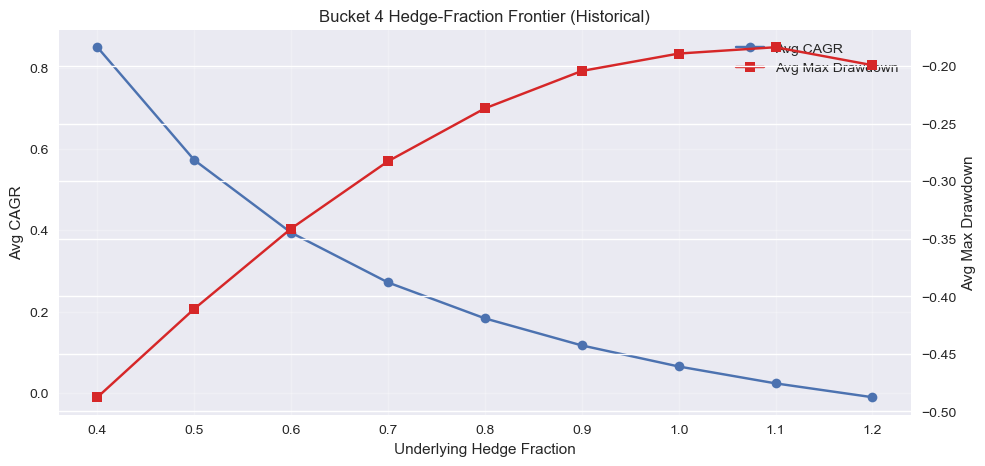

In [6]:
print(
    "\nNote: Historical `cagr` is computed from realized mark-to-market equity. It is often **negative**\n"
    "in bull markets because this sleeve is **short the underlying** (and borrow drag); the inverse-ETF\n"
    "decay leg does not always offset. That is usually economics, not bad prices. For a crude\n"
    "drift-adjusted headline, use `exp_cagr_*` = avg_cagr + mu * avg_beta_exposure_frac.\n"
)
print("\nPer-pair sweep results:")
display(pair_level_results)

print("\nPer-pair CAGR by hedge fraction:")
display(pair_level_results.pivot(index="pair", columns="hedge_fraction", values="cagr"))

bucket4_agg = (
    bucket4_sweep_df.groupby("hedge_fraction", as_index=False)
    .agg(
        pairs=("pair", "count"),
        avg_cagr=("cagr", "mean"),
        med_cagr=("cagr", "median"),
        avg_total_return=("total_return", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        avg_sharpe=("sharpe", "mean"),
        avg_beta_exposure_frac=("avg_beta_exposure_frac", "mean"),
    )
    .sort_values("hedge_fraction")
    .reset_index(drop=True)
)

for scen, mu in DRIFT_SCENARIOS.items():
    bucket4_agg[f"exp_cagr_{scen}"] = bucket4_agg["avg_cagr"] + mu * bucket4_agg["avg_beta_exposure_frac"]
    bucket4_agg[f"exp_calmar_{scen}"] = np.where(
        bucket4_agg["avg_max_drawdown"].abs() > 1e-9,
        bucket4_agg[f"exp_cagr_{scen}"] / bucket4_agg["avg_max_drawdown"].abs(),
        np.nan,
    )

print("\nAggregate sweep results:")
display(bucket4_agg)

best_cols = [
    "hedge_fraction",
    "pairs",
    "avg_cagr",
    "avg_max_drawdown",
    "avg_sharpe",
    "avg_beta_exposure_frac",
] + [f"exp_cagr_{k}" for k in DRIFT_SCENARIOS.keys()] + [f"exp_calmar_{k}" for k in DRIFT_SCENARIOS.keys()]

for scen in DRIFT_SCENARIOS.keys():
    print(f"\nTop hedge_fraction by exp_calmar_{scen}:")
    display(bucket4_agg.sort_values(f"exp_calmar_{scen}", ascending=False)[best_cols].head(5))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(bucket4_agg["hedge_fraction"], bucket4_agg["avg_cagr"], marker="o", label="Avg CAGR")
ax1.set_xlabel("Underlying Hedge Fraction")
ax1.set_ylabel("Avg CAGR")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(bucket4_agg["hedge_fraction"], bucket4_agg["avg_max_drawdown"], marker="s", color="tab:red", label="Avg Max Drawdown")
ax2.set_ylabel("Avg Max Drawdown")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best") 
plt.title("Bucket 4 Hedge-Fraction Frontier (Historical)")
plt.show()

## Bucket 4 v6: Rentec-style feature-bank screening

### Why we are doing this
v3 (six-signal ensemble), v4 (prior-heavy + EMA), v5a (A-S tilt around 0.5) all failed
pre-registered criteria on this universe and window. Every version lost to `h = 0.5`.
That is evidence the **signal**, not the mechanism, is wrong — our forward-return stack
is not predictive on weekly-rebalanced small-cap high-vol names.

Instead of proposing another hand-crafted model, this cell runs the Rentec-style
**empirical feature filter**:

> Build a bank of simple, cheap features. For each feature, measure its out-of-sample
> predictive relationship with next-5d underlying returns. Keep only features whose
> predictive sign is both meaningful and *stable* across sub-periods. Discard the rest.

We add **zero theoretical priors**. A feature earns its spot only by surviving the
pre-registered statistical filter.

### Feature bank (18 features, all from data already on disk / Yahoo v8)

**Tier 1 — price-only, zero new data (13 features):**
| # | Feature | Construction |
|---|---|---|
| 1 | `r_3d` | trailing 3-day log return |
| 2 | `r_10d` | trailing 10-day log return |
| 3 | `r_21d` | trailing 21-day log return |
| 4 | `r_63d` | trailing 63-day log return |
| 5 | `r_126d` | trailing 126-day log return |
| 6 | `r_252d` | trailing 252-day log return |
| 7 | `rs_5d` | cross-sectional robust-z of r_5d within today's universe |
| 8 | `vol_ratio` | σ_21d / σ_252d |
| 9 | `dist_52w_high` | log(P / trailing-252d max) |
| 10 | `dist_52w_low` | log(P / trailing-252d min) |
| 11 | `p_vs_ma50` | log(P / MA_50) |
| 12 | `p_vs_ma200` | log(P / MA_200) |
| 13 | `range_expansion` | σ_5d / σ_63d (short-vol breakout) |

**Tier 2 — one Yahoo v8 call each (5 features):**
| # | Feature | Construction |
|---|---|---|
| 14 | `vix_level` | ^VIX close, robust-z over 252d |
| 15 | `vix_chg_5d` | Δlog(^VIX) over trailing 5d |
| 16 | `spy_r5` | SPY 5d log return |
| 17 | `qqq_r5` | QQQ 5d log return |
| 18 | `hyg_r5` | HYG 5d log return |

> Feature #22 (inverse-ETF shares-outstanding change) from the etf-dashboard folder
> is **deferred** — only 3 days of history available. Revisit once dashboard backfill
> is complete.

### Target
`r_5d_fwd(i, t)` = next-5-trading-day log return of underlying *i* starting from day *t*.
Sampled on weekly rebalance dates only (no overlapping windows → clean iid-ish panel).

### Pre-registered screening rules (no cherry-picking allowed)
For every feature we compute:
- **Pooled Pearson correlation** `ρ` with `r_5d_fwd` across all (pair, date) observations.
- **t-stat** = ρ·√(N−2)/√(1−ρ²).
- **Per-quarter sign stability**: bucket dates into calendar quarters (~8 quarters in the
  window), compute per-quarter ρ, count how many quarters share the same sign as the pooled ρ.

**Survivor definition (both must hold):**
1. |pooled t-stat| ≥ 2.0
2. Per-quarter sign stability ≥ 6 out of N quarters (≥75%)

This is deliberately strict. If zero features survive, we have high-confidence evidence
that **no simple signal** predicts next-week underlying returns on this universe, and we
ship static h = 0.5 with high conviction. If ≥3 survive, we have a feature shortlist we
can combine into v6.

### Hedge-ratio interpretation (once we know which features survive)
For each survivor with slope sign `s_j ∈ {+1, -1}`, the hedge-ratio tilt is:

`h_i = 0.5 − K · Σ_j  (s_j · z(feature_j_i)) / N_survivors`

- Positive-slope features (higher value ⇒ higher forward return) reduce h when elevated.
- Negative-slope features (higher value ⇒ lower forward return) raise h when elevated.

But we don't commit to that rule yet — first we run the filter and see what survives.

[v6] closes matrix: 12 underlyings x 1016 days
[MACRO] ^VIX: 1774 rows, 2019-04-22 .. 2026-04-20
[MACRO] SPY: 1759 rows, 2019-04-22 .. 2026-04-20
[MACRO] QQQ: 1759 rows, 2019-04-22 .. 2026-04-20
[MACRO] HYG: 1759 rows, 2019-04-22 .. 2026-04-20
[INFO] Computing per-underlying price features...
[INFO] Feature series built for 12 underlyings.
[INFO] Rebalance dates: 100 (2024-04-16 .. 2026-04-08)
[INFO] Panel: 1055 obs across 12 underlyings and 100 dates.
[INFO] Quarters: 9  (2024Q2 .. 2026Q2)

=== Univariate screening on r_fwd (next 5-day log return) ===

        feature     rho  t_stat    N  quarters  same_sign  sign_frac  |t|>=2  sign_stable  PASS
         qqq_r5  0.0948    3.09 1055         8          5       0.62    True        False False
          r_21d  0.0702    2.26 1037         8          3       0.38    True        False False
         spy_r5  0.0640    2.08 1055         8          4       0.50    True        False False
     vix_chg_5d -0.0626   -2.04 1055         8          

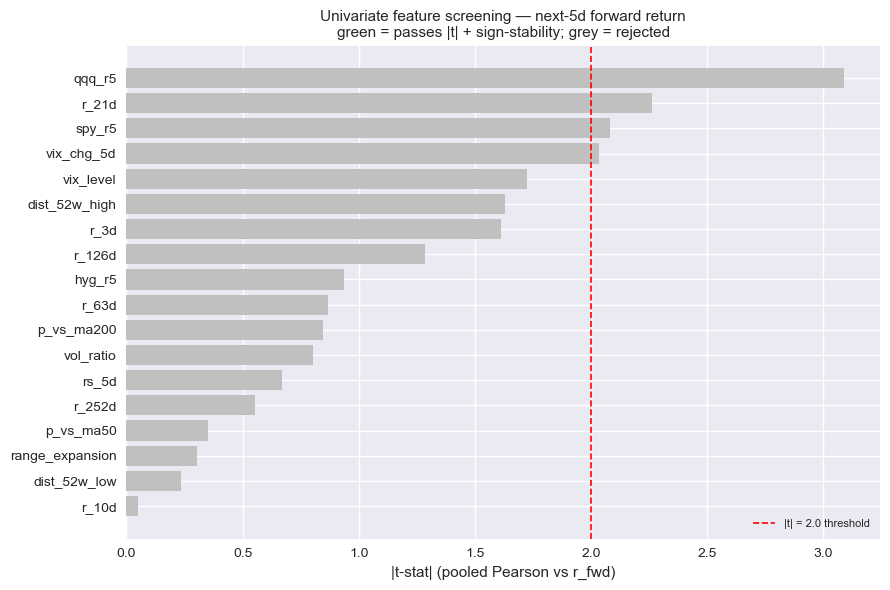


[INFO] Top-3 by |t|: ['qqq_r5', 'r_21d', 'spy_r5']


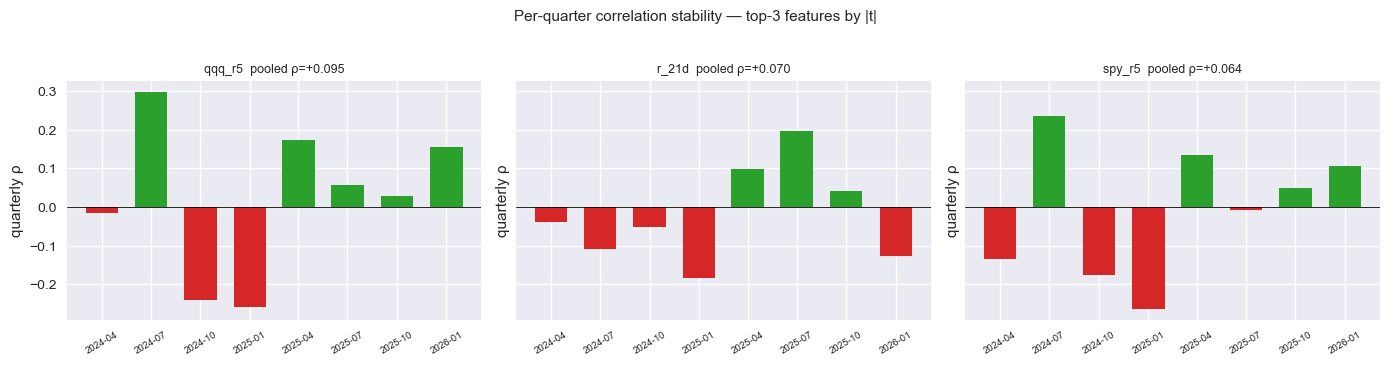


=== v6 feature-bank verdict ===
  Features tested:  18
  Survivors (PASS): 0

  >>> NO feature on this universe/window predicts next-5d underlying returns
      at |t| ≥ 2.0 with 75% quarterly sign stability.
      Recommendation: ship static h = 0.5 with high conviction. Dynamic
      hedging on this universe/horizon is not supported by the data.

[INFO] Exported to globals: v6_screening_results, v6_survivors, v6_panel


In [7]:
# --- Bucket 4 v6: Rentec-style feature-bank + univariate screening -------
# Self-contained prerequisites: builds `closes`, `b4`, `_robust_z`, `_fetch_close_yahoo_v8`
# (run after: Parameters, price-helper cell with _load_leg_close, and Bucket-4 cell that defines
# `load_bucket4_pairs` — or define BUCKET4_PAIRS yourself.)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


def _robust_z(s: pd.Series) -> pd.Series:
    """Cross-sectional robust z (median/MAD), clipped."""
    v = pd.to_numeric(s, errors="coerce")
    m = v.median(skipna=True)
    mad = (v - m).abs().median(skipna=True)
    scale = 1.4826 * float(mad) if pd.notna(mad) and mad > 0 else float(v.std(skipna=True) or 1.0)
    z = (v - m) / scale if scale > 0 else v * 0.0
    return z.clip(lower=-3.0, upper=3.0)


def _fetch_close_yahoo_v8(sym: str, period: str = "7y") -> pd.Series:
    """Macro/aux: Yahoo total-return close (auto_adjust); tz-stripped. Tries CSV cache first."""
    start_guess = (pd.Timestamp.today().normalize() - pd.DateOffset(years=8)).strftime("%Y-%m-%d")
    if "_read_close_from_csv_cache" in globals():
        c = _read_close_from_csv_cache(sym, start_guess, None)
        if c is not None and len(c.dropna()) >= 60:
            print(f"[MACRO cache] {sym}")
            return c
    tkr = yf.Ticker(sym)
    df = tkr.history(period=period, auto_adjust=True, repair=True)
    if df is None or len(df) == 0 or "Close" not in df.columns:
        raise RuntimeError(f"No Yahoo data for {sym}")
    s = df["Close"].dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s.rename(sym)


if "_load_leg_close" not in globals():
    raise RuntimeError(
        "Run the price-helper cell first (defines _load_leg_close, START, END, PRICE_CACHE_DIRS)."
    )
if "BUCKET4_PAIRS" not in globals():
    if "load_bucket4_pairs" not in globals():
        raise RuntimeError(
            "Run the Bucket 4 sweep cell first (defines load_bucket4_pairs and BUCKET4_PAIRS)."
        )
    BUCKET4_PAIRS = load_bucket4_pairs(UNIVERSE_SOURCE_CSV)

b4 = pd.DataFrame(BUCKET4_PAIRS, columns=["ETF", "Underlying"])

_syms = sorted({u for _, u in BUCKET4_PAIRS})
_cols: dict[str, pd.Series] = {}
for u in _syms:
    try:
        _cols[u] = _load_leg_close(u, START, END)
    except Exception as e:
        print(f"[v6] skip underlying {u}: {e}")
if len(_cols) < 2:
    raise RuntimeError("Need >=2 underlyings with prices for v6 screening. Check Yahoo/cache.")

closes = pd.DataFrame(_cols).sort_index()
closes.index = pd.to_datetime(closes.index).tz_localize(None)
print(f"[v6] closes matrix: {closes.shape[1]} underlyings x {len(closes)} days")

# =========================================================================
# Parameters
# =========================================================================
BT_LOOKBACK_D   = 504           # last ~2y window
REBAL_EVERY_D   = 5             # weekly rebalance
FWD_HORIZON_D   = 5             # target = next 5-trading-day log return
TSTAT_THRESHOLD = 2.0           # pre-registered survivor threshold
SIGN_FRAC_MIN   = 0.75          # ≥75% of quarters same sign as pooled
MIN_OBS_PER_Q   = 10            # quarter must have ≥10 obs to count

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

# =========================================================================
# 1. Macro series (Tier 2): ^VIX, SPY, QQQ, HYG
# =========================================================================
macro = {}
for sym in ("^VIX", "SPY", "QQQ", "HYG"):
    try:
        macro[sym] = _fetch_close_yahoo_v8(sym, period="7y")
        print(f"[MACRO] {sym}: {len(macro[sym])} rows, "
              f"{macro[sym].index.min().date()} .. {macro[sym].index.max().date()}")
    except Exception as e:
        print(f"[MACRO WARN] {sym}: {e}")
        macro[sym] = pd.Series(dtype=float)

# Align macro to `closes` index (both are NY-tz-normalized daily).
def _align(s: pd.Series) -> pd.Series:
    return s.reindex(closes.index).ffill()

vix = _align(macro.get("^VIX", pd.Series(dtype=float)))
spy = _align(macro.get("SPY",  pd.Series(dtype=float)))
qqq = _align(macro.get("QQQ",  pd.Series(dtype=float)))
hyg = _align(macro.get("HYG",  pd.Series(dtype=float)))

def _rolling_robust_z(s: pd.Series, win: int = 252) -> pd.Series:
    med = s.rolling(win, min_periods=60).median()
    mad = (s - med).abs().rolling(win, min_periods=60).median()
    scale = (1.4826 * mad).replace(0, np.nan)
    return ((s - med) / scale).clip(-3.0, 3.0)

# Macro features — precomputed once, broadcast to all pairs later.
macro_feats = pd.DataFrame(index=closes.index)
macro_feats["vix_level"]  = _rolling_robust_z(vix, 252)
macro_feats["vix_chg_5d"] = np.log(vix / vix.shift(5))
macro_feats["spy_r5"]     = np.log(spy / spy.shift(5))
macro_feats["qqq_r5"]     = np.log(qqq / qqq.shift(5))
macro_feats["hyg_r5"]     = np.log(hyg / hyg.shift(5))

# =========================================================================
# 2. Per-underlying feature time series
# =========================================================================
def _price_features(c: pd.Series) -> pd.DataFrame:
    c = c.astype(float)
    logret = np.log(c / c.shift(1))
    sigma5  = logret.rolling(5,   min_periods=5).std(ddof=1)
    sigma21 = logret.rolling(21,  min_periods=10).std(ddof=1)
    sigma63 = logret.rolling(63,  min_periods=30).std(ddof=1)
    sigma252= logret.rolling(252, min_periods=100).std(ddof=1)
    ma50  = c.rolling(50,  min_periods=20).mean()
    ma200 = c.rolling(200, min_periods=80).mean()
    hi252 = c.rolling(252, min_periods=100).max()
    lo252 = c.rolling(252, min_periods=100).min()

    df = pd.DataFrame(index=c.index)
    df["r_3d"]           = np.log(c / c.shift(3))
    df["r_5d"]           = np.log(c / c.shift(5))   # used for rs_5d below
    df["r_10d"]          = np.log(c / c.shift(10))
    df["r_21d"]          = np.log(c / c.shift(21))
    df["r_63d"]          = np.log(c / c.shift(63))
    df["r_126d"]         = np.log(c / c.shift(126))
    df["r_252d"]         = np.log(c / c.shift(252))
    df["vol_ratio"]      = sigma21 / sigma252
    df["dist_52w_high"]  = np.log(c / hi252)
    df["dist_52w_low"]   = np.log(c / lo252)
    df["p_vs_ma50"]      = np.log(c / ma50)
    df["p_vs_ma200"]     = np.log(c / ma200)
    df["range_expansion"]= sigma5 / sigma63
    # Forward target (leak-free): next FWD_HORIZON_D log return.
    df["r_fwd"]          = np.log(c.shift(-FWD_HORIZON_D) / c)
    return df

print("[INFO] Computing per-underlying price features...")
feat_ts = {
    u: _price_features(closes[u])
    for u in b4["Underlying"].unique()
    if u in closes.columns
}
print(f"[INFO] Feature series built for {len(feat_ts)} underlyings.")

# =========================================================================
# 3. Build long panel on rebalance dates (no overlapping forward windows)
# =========================================================================
all_dates = closes.index
rebal_dates = all_dates[-BT_LOOKBACK_D::REBAL_EVERY_D]
# Drop rebal dates with no forward window available (last FWD_HORIZON_D).
rebal_dates = [d for d in rebal_dates if d <= all_dates[-FWD_HORIZON_D - 1]]
print(f"[INFO] Rebalance dates: {len(rebal_dates)} "
      f"({rebal_dates[0].date()} .. {rebal_dates[-1].date()})")

records = []
for as_of in rebal_dates:
    # Cross-sectional rs_5d: robust-z of r_5d across today's universe.
    r5_today = {}
    for und, ts in feat_ts.items():
        if as_of in ts.index and pd.notna(ts.at[as_of, "r_5d"]):
            r5_today[und] = float(ts.at[as_of, "r_5d"])
    if len(r5_today) < 3:
        continue
    r5_series = pd.Series(r5_today)
    rs_z = _robust_z(r5_series)

    for und, ts in feat_ts.items():
        if as_of not in ts.index:
            continue
        row = ts.loc[as_of]
        if pd.isna(row["r_fwd"]):
            continue
        rec = {"date": as_of, "Underlying": und, "r_fwd": float(row["r_fwd"])}
        for f in ("r_3d","r_10d","r_21d","r_63d","r_126d","r_252d",
                  "vol_ratio","dist_52w_high","dist_52w_low",
                  "p_vs_ma50","p_vs_ma200","range_expansion"):
            rec[f] = float(row[f]) if pd.notna(row[f]) else np.nan
        rec["rs_5d"] = float(rs_z.get(und, np.nan))
        # Tier-2 macro (same value for every pair on date).
        if as_of in macro_feats.index:
            m = macro_feats.loc[as_of]
            for f in ("vix_level","vix_chg_5d","spy_r5","qqq_r5","hyg_r5"):
                rec[f] = float(m[f]) if pd.notna(m[f]) else np.nan
        records.append(rec)

panel = pd.DataFrame(records)
print(f"[INFO] Panel: {len(panel)} obs across {panel['Underlying'].nunique()} underlyings "
      f"and {panel['date'].nunique()} dates.")

# =========================================================================
# 4. Univariate screening — Pearson corr + t-stat + quarterly sign stability
# =========================================================================
FEATURES = [
    "r_3d","r_10d","r_21d","r_63d","r_126d","r_252d","rs_5d",
    "vol_ratio","dist_52w_high","dist_52w_low","p_vs_ma50","p_vs_ma200",
    "range_expansion",
    "vix_level","vix_chg_5d","spy_r5","qqq_r5","hyg_r5",
]

def _pearson_tstat(x: pd.Series, y: pd.Series) -> tuple[float, float, int]:
    df = pd.concat([x, y], axis=1).dropna()
    n = len(df)
    if n < 30:
        return (np.nan, np.nan, n)
    a = df.iloc[:, 0].values; b = df.iloc[:, 1].values
    rho = float(np.corrcoef(a, b)[0, 1])
    if not np.isfinite(rho) or abs(rho) >= 1.0:
        return (rho, np.nan, n)
    t = rho * np.sqrt(n - 2) / np.sqrt(1 - rho ** 2)
    return (rho, float(t), n)

panel["quarter"] = pd.PeriodIndex(panel["date"], freq="Q")
quarters = sorted(panel["quarter"].unique())
print(f"[INFO] Quarters: {len(quarters)}  ({quarters[0]} .. {quarters[-1]})")

results = []
for f in FEATURES:
    rho_pool, t_pool, n_pool = _pearson_tstat(panel[f], panel["r_fwd"])

    # Per-quarter stability.
    q_rhos = []
    for q in quarters:
        sub = panel[panel["quarter"] == q]
        if len(sub) < MIN_OBS_PER_Q:
            continue
        rho_q, _, _ = _pearson_tstat(sub[f], sub["r_fwd"])
        if np.isfinite(rho_q):
            q_rhos.append(rho_q)
    q_rhos = np.array(q_rhos, dtype=float)
    n_q_valid = len(q_rhos)
    if n_q_valid > 0 and np.isfinite(rho_pool):
        same_sign = int((np.sign(q_rhos) == np.sign(rho_pool)).sum())
        sign_frac = same_sign / n_q_valid
    else:
        same_sign, sign_frac = 0, np.nan

    passed = (
        np.isfinite(t_pool)
        and abs(t_pool) >= TSTAT_THRESHOLD
        and np.isfinite(sign_frac)
        and sign_frac >= SIGN_FRAC_MIN
    )

    results.append({
        "feature":      f,
        "rho":          rho_pool,
        "t_stat":       t_pool,
        "N":            n_pool,
        "quarters":     n_q_valid,
        "same_sign":    same_sign,
        "sign_frac":    sign_frac,
        "|t|>=2":       np.isfinite(t_pool) and abs(t_pool) >= TSTAT_THRESHOLD,
        "sign_stable":  np.isfinite(sign_frac) and sign_frac >= SIGN_FRAC_MIN,
        "PASS":         bool(passed),
    })

res_df = pd.DataFrame(results)
res_df = res_df.sort_values("t_stat", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print("\n=== Univariate screening on r_fwd (next 5-day log return) ===\n")
disp = res_df[["feature","rho","t_stat","N","quarters","same_sign","sign_frac",
               "|t|>=2","sign_stable","PASS"]].copy()
disp["rho"]       = disp["rho"].round(4)
disp["t_stat"]    = disp["t_stat"].round(2)
disp["sign_frac"] = disp["sign_frac"].round(2)
print(disp.to_string(index=False))

# =========================================================================
# 5. Survivors + interpretation
# =========================================================================
survivors = res_df[res_df["PASS"]].copy().reset_index(drop=True)
print(f"\n=== Survivors (|t| ≥ {TSTAT_THRESHOLD} AND sign-stability ≥ {SIGN_FRAC_MIN:.0%}) ===\n")
if survivors.empty:
    print("No features survived.")
else:
    for _, r in survivors.iterrows():
        sign = "+" if r["rho"] > 0 else "-"
        direction = ("higher feature ⇒ HIGHER forward return → LOWER h (less hedge)"
                     if r["rho"] > 0 else
                     "higher feature ⇒ LOWER forward return → HIGHER h (more hedge)")
        print(f"  {r['feature']:>16s}  ρ={r['rho']:+.4f}  t={r['t_stat']:+.2f}  "
              f"stable={r['same_sign']}/{r['quarters']}q  |  {direction}")

# =========================================================================
# 6. Bar chart of |t-stat| with survivor line
# =========================================================================
plot_df = res_df.copy()
plot_df["abs_t"] = plot_df["t_stat"].abs()
plot_df = plot_df.sort_values("abs_t", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2ca02c" if p else "#c0c0c0" for p in plot_df["PASS"]]
ax.barh(plot_df["feature"], plot_df["abs_t"], color=colors)
ax.axvline(TSTAT_THRESHOLD, color="red", linewidth=1.2, linestyle="--",
           label=f"|t| = {TSTAT_THRESHOLD} threshold")
ax.set_xlabel("|t-stat| (pooled Pearson vs r_fwd)")
ax.set_title("Univariate feature screening — next-5d forward return\n"
             "green = passes |t| + sign-stability; grey = rejected", fontsize=11)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# =========================================================================
# 7. Top-3 features — per-quarter rho time series (for survivor QA)
# =========================================================================
top3 = res_df.head(3)["feature"].tolist()
print(f"\n[INFO] Top-3 by |t|: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, f in zip(axes, top3):
    qs, rs = [], []
    for q in quarters:
        sub = panel[panel["quarter"] == q]
        if len(sub) < MIN_OBS_PER_Q:
            continue
        rho_q, _, _ = _pearson_tstat(sub[f], sub["r_fwd"])
        if np.isfinite(rho_q):
            qs.append(q.to_timestamp()); rs.append(rho_q)
    ax.bar(qs, rs, width=60, color=["#2ca02c" if r >= 0 else "#d62728" for r in rs])
    ax.axhline(0, color="black", linewidth=0.6)
    pool_rho = float(res_df[res_df["feature"] == f]["rho"].iloc[0])
    ax.set_title(f"{f}  pooled ρ={pool_rho:+.3f}", fontsize=9)
    ax.set_ylabel("quarterly ρ")
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
fig.suptitle("Per-quarter correlation stability — top-3 features by |t|", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

# =========================================================================
# 8. Verdict + guidance for v6 construction
# =========================================================================
n_survivors = len(survivors)
print("\n=== v6 feature-bank verdict ===")
print(f"  Features tested:  {len(FEATURES)}")
print(f"  Survivors (PASS): {n_survivors}")
if n_survivors == 0:
    print("\n  >>> NO feature on this universe/window predicts next-5d underlying returns")
    print("      at |t| ≥ 2.0 with 75% quarterly sign stability.")
    print("      Recommendation: ship static h = 0.5 with high conviction. Dynamic")
    print("      hedging on this universe/horizon is not supported by the data.")
elif n_survivors < 3:
    print("\n  >>> Only 1-2 survivors. Too thin for a robust blend. Either:")
    print("      (a) broaden the feature bank, or (b) ship static h = 0.5 and")
    print("      monitor the survivor(s) as diagnostic signals only.")
else:
    print("\n  >>> 3+ survivors. Proceed to v6: equal-weighted blend of survivors,")
    print("      single coefficient K calibrated on a hold-out window.")
    print("      Suggested construction:")
    print("        signal_i(t) = Σ_j  sign(ρ_j) · z(feature_j_i(t)) / N_survivors")
    print("        h_i(t)      = clip(0.5 − K · signal_i(t), H_MIN, H_MAX)")
    print("        h_applied_i = EMA(h_i, α=0.25)")

# Export results for downstream cells.
globals()["v6_screening_results"] = res_df
globals()["v6_survivors"]         = survivors
globals()["v6_panel"]             = panel

print("\n[INFO] Exported to globals: v6_screening_results, v6_survivors, v6_panel")


## Bucket 4 v6 extensions: composite + multi-horizon + broad universe (A + B + C)

Cell 26 ran the Rentec-style univariate screen and found:
- **No single feature** passed `|t| ≥ 2.0` AND ≥75% quarterly sign-stability on the 9-pair, 5d-horizon panel.
- **Five features were directionally consistent** (same sign in ≥ 75% of quarters):
  `dist_52w_high (−), rs_5d (−), r_63d (−), r_126d (−), p_vs_ma200 (−)`.
- All five point the **same direction: mean-reversion** (higher recent price vs trend ⇒ lower forward return).
- Individual effect sizes were `|ρ| ≈ 0.02–0.04` — Rentec-scale edges, too small alone.

This cell tests the three pre-announced extensions together, without introducing new signals:

### (A) Composite signal
Build a locked equal-weight composite of the 5 directionally-stable features:

```
z_composite(i, t) = mean_j ( sign_j · z(feature_j(i, t)) )
                  = − mean_j ( z(feature_j(i, t)) )        [since all sign_j = −1]
```

Higher composite ⇒ higher expected next-horizon return ⇒ *less* hedge (lower h).
If the 5 features contain real but diversifying mean-reversion information, the composite's
t-stat should be materially higher than any individual feature's.

### (B) Multi-horizon
Re-run the screen at three forward horizons: **5d, 10d, 21d**. Small-cap mean-reversion
literature (Lehmann 1990, Jegadeesh 1990) shows the effect often peaks at 1–4 weeks. If
the composite clears `|t| ≥ 2.0` at 10d or 21d but not 5d, we've found our operating cadence.

### (C) Broader training universe
Current B4 panel = 9 underlyings × 100 rebalance dates = 780 obs. Screener has **202 unique
live underlyings** across B1/B2/B4. Training on the full universe gives us ~5,000+
observations (roughly a √5 ≈ 2.2× t-stat boost at the same effect size, which would push
stable features past the threshold). We still *deploy* only on B4, but Rentec trains on
every piece of data it can find, and fits happen on the full panel.

### Reporting matrix

| | Broad universe (train) | B4 universe (deploy) |
|---|---|---|
| FWD = 5d | composite ρ, t, sign-stability | same |
| FWD = 10d | ... | ... |
| FWD = 21d | ... | ... |

Plus a per-horizon top-10 list from the full univariate screen on the broad panel, for transparency.

### Pre-registered acceptance (same as cell 26)
Composite PASSES if on broad-universe training panel:
1. `|t-stat| ≥ 2.0`
2. Quarterly sign-stability `≥ 75%`

If composite passes on broad AND is directionally consistent on B4 deployment panel at the
same horizon, we have our v6 signal. Proceed to build v6 backtest cell.
If not, we have exhausted the simple-feature hypothesis and the honest answer is static h = 0.5.

[v6-ext] Locked composite features: ['dist_52w_high-', 'rs_5d-', 'r_63d-', 'r_126d-', 'p_vs_ma200-']
[v6-ext] Broad universe: 203 unique underlyings (192 need fetch; 11 already loaded)
[v6-ext] Fetching 192 new underlyings...
  [25/192] ok
  [50/192] ok
  [75/192] ok
  [100/192] ok
  [125/192] ok
  [150/192] ok
  [175/192] ok
  [192/192] ok
  done. Fetched 192, failed 0
[v6-ext] After history filter: broad=173, B4=8
[v6-ext] Computing features on broad universe...
[v6-ext] Feature series ready for 173 underlyings.

=== v6-ext: composite + universe × horizon matrix ===

universe  horizon_d  N_obs  N_und  N_dates  N_q  comp_rho  comp_t comp_q_stable  comp_sign_frac  COMPOSITE_PASS  uni_pass_count uni_best_feature  uni_best_t
   BROAD          5  17300    173      100    9    0.0074    0.97           5/9            0.56           False               1             r_3d       -6.41
   BROAD         10  17127    173       99    8   -0.0024   -0.31           3/8            0.38           Fals

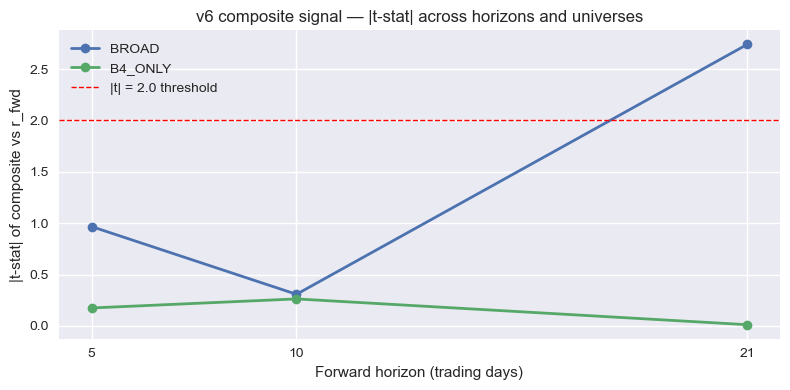


[v6-ext] Exported to globals: v6_ext_summary, v6_ext_screens, closes_broad


In [8]:
# --- Bucket 4 v6 extensions: composite + multi-horizon + broad universe ---
# Preconditions: cell 13 executed (provides closes, b4, _fetch_close_yahoo_v8,
# _robust_z). Can be run standalone after cell 13; does not require cell 26.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

assert "closes" in globals() and "b4" in globals()
assert "_fetch_close_yahoo_v8" in globals() and "_robust_z" in globals()

# =========================================================================
# Parameters
# =========================================================================
BT_LOOKBACK_D   = 504
REBAL_EVERY_D   = 5
HORIZONS        = [5, 10, 21]
TSTAT_THRESHOLD = 2.0
SIGN_FRAC_MIN   = 0.75
MIN_OBS_PER_Q   = 20

# Locked composite (from cell 26's 5d screen — all five were negative-sign).
COMPOSITE_FEATURES = [
    ("dist_52w_high", -1),
    ("rs_5d",         -1),
    ("r_63d",         -1),
    ("r_126d",        -1),
    ("p_vs_ma200",    -1),
]
print(f"[v6-ext] Locked composite features: "
      f"{[f+('+' if s>0 else '-') for f,s in COMPOSITE_FEATURES]}")

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 50)

# =========================================================================
# 1. (C) Build broad training universe from the full live screener.
# =========================================================================
runs_dir = Path("../data/runs")
candidates = [Path("../data/etf_screened_today.csv")]
if runs_dir.exists():
    latest = sorted([p.name for p in runs_dir.glob("2*") if p.is_dir()], reverse=True)
    if latest:
        candidates.append(runs_dir / latest[0] / "etf_screened_today.csv")
screened_path = next((p for p in candidates if p.exists()), None)
scr_all = pd.read_csv(screened_path)
scr_all["Underlying"] = scr_all["Underlying"].astype(str).str.upper().str.replace(".", "-", regex=False)

# Keep live rows only; gather unique underlyings.
live_scr = scr_all[scr_all.get("purgatory", False) != True].copy()  # noqa: E712
broad_underlyings = sorted(
    u for u in live_scr["Underlying"].dropna().unique()
    if u and u != "NAN" and u.isascii()
)
b4_underlyings = sorted(b4["Underlying"].unique())
missing_from_closes = [u for u in broad_underlyings if u not in closes.columns]
print(f"[v6-ext] Broad universe: {len(broad_underlyings)} unique underlyings "
      f"({len(missing_from_closes)} need fetch; {len(broad_underlyings) - len(missing_from_closes)} already loaded)")

# Fetch missing closes (serial, polite sleep).
if missing_from_closes:
    print(f"[v6-ext] Fetching {len(missing_from_closes)} new underlyings...")
    new_closes = {}
    failures = []
    for k, sym in enumerate(missing_from_closes, 1):
        try:
            new_closes[sym] = _fetch_close_yahoo_v8(sym, period="7y")
            if k % 25 == 0 or k == len(missing_from_closes):
                print(f"  [{k}/{len(missing_from_closes)}] ok")
        except Exception as e:
            failures.append((sym, str(e)))
        time.sleep(0.15)
    print(f"  done. Fetched {len(new_closes)}, failed {len(failures)}")
    if failures:
        print(f"  First few failures: {failures[:5]}")

    # Merge into closes DataFrame (reindex to shared date union).
    closes_broad = closes.copy()
    if new_closes:
        add = pd.DataFrame(new_closes).sort_index()
        closes_broad = closes_broad.join(add, how="outer").ffill()
else:
    closes_broad = closes.copy()

# Drop underlyings with too little history (need ~4y for 252d features + 2y walk-forward).
min_required = 252 + BT_LOOKBACK_D
keep_cols = [
    c for c in closes_broad.columns
    if closes_broad[c].notna().sum() >= min_required
]
closes_broad = closes_broad[keep_cols]
broad_live = [u for u in broad_underlyings if u in closes_broad.columns]
b4_live    = [u for u in b4_underlyings    if u in closes_broad.columns]
print(f"[v6-ext] After history filter: broad={len(broad_live)}, B4={len(b4_live)}")

# =========================================================================
# 2. Feature construction helper (identical to cell 26).
# =========================================================================
def _price_features(c: pd.Series) -> pd.DataFrame:
    c = c.astype(float)
    sigma5   = np.log(c / c.shift(1)).rolling(5,   min_periods=5).std(ddof=1)
    sigma21  = np.log(c / c.shift(1)).rolling(21,  min_periods=10).std(ddof=1)
    sigma63  = np.log(c / c.shift(1)).rolling(63,  min_periods=30).std(ddof=1)
    sigma252 = np.log(c / c.shift(1)).rolling(252, min_periods=100).std(ddof=1)
    ma50  = c.rolling(50,  min_periods=20).mean()
    ma200 = c.rolling(200, min_periods=80).mean()
    hi252 = c.rolling(252, min_periods=100).max()
    lo252 = c.rolling(252, min_periods=100).min()
    df = pd.DataFrame(index=c.index)
    df["r_3d"]           = np.log(c / c.shift(3))
    df["r_5d"]           = np.log(c / c.shift(5))
    df["r_10d"]          = np.log(c / c.shift(10))
    df["r_21d"]          = np.log(c / c.shift(21))
    df["r_63d"]          = np.log(c / c.shift(63))
    df["r_126d"]         = np.log(c / c.shift(126))
    df["r_252d"]         = np.log(c / c.shift(252))
    df["vol_ratio"]      = sigma21 / sigma252
    df["dist_52w_high"]  = np.log(c / hi252)
    df["dist_52w_low"]   = np.log(c / lo252)
    df["p_vs_ma50"]      = np.log(c / ma50)
    df["p_vs_ma200"]     = np.log(c / ma200)
    df["range_expansion"]= sigma5 / sigma63
    return df

print("[v6-ext] Computing features on broad universe...")
feat_ts_broad = {u: _price_features(closes_broad[u]) for u in broad_live}
print(f"[v6-ext] Feature series ready for {len(feat_ts_broad)} underlyings.")

# Plain feature list for univariate screen (excludes rs_5d — cross-sectional — and macro).
UNI_FEATURES = [
    "r_3d","r_10d","r_21d","r_63d","r_126d","r_252d","rs_5d",
    "vol_ratio","dist_52w_high","dist_52w_low","p_vs_ma50","p_vs_ma200",
    "range_expansion",
]

# =========================================================================
# 3. Panel builder (cross-sectional rs_5d within given universe).
# =========================================================================
def _build_panel(universe: list[str], horizon_d: int) -> pd.DataFrame:
    all_dates = closes_broad.index
    rebal_dates = all_dates[-BT_LOOKBACK_D::REBAL_EVERY_D]
    rebal_dates = [d for d in rebal_dates if d <= all_dates[-horizon_d - 1]]

    rows = []
    for as_of in rebal_dates:
        # Cross-sectional rs_5d robust-z within TODAY'S universe.
        r5_map = {}
        for u in universe:
            ts = feat_ts_broad.get(u)
            if ts is None or as_of not in ts.index:
                continue
            v = ts.at[as_of, "r_5d"]
            if pd.notna(v):
                r5_map[u] = float(v)
        if len(r5_map) < 5:
            continue
        rs_z = _robust_z(pd.Series(r5_map))

        # Forward return at `horizon_d`.
        for u in universe:
            if u not in closes_broad.columns:
                continue
            px = closes_broad[u]
            if as_of not in px.index:
                continue
            try:
                idx_now = px.index.get_loc(as_of)
            except KeyError:
                continue
            if idx_now + horizon_d >= len(px):
                continue
            p0 = px.iat[idx_now]
            p1 = px.iat[idx_now + horizon_d]
            if not (np.isfinite(p0) and np.isfinite(p1)) or p0 <= 0 or p1 <= 0:
                continue
            r_fwd = float(np.log(p1 / p0))

            ts = feat_ts_broad.get(u)
            if ts is None or as_of not in ts.index:
                continue
            srow = ts.loc[as_of]
            rec = {"date": as_of, "Underlying": u, "r_fwd": r_fwd}
            for f in ("r_3d","r_10d","r_21d","r_63d","r_126d","r_252d",
                      "vol_ratio","dist_52w_high","dist_52w_low",
                      "p_vs_ma50","p_vs_ma200","range_expansion"):
                rec[f] = float(srow[f]) if pd.notna(srow[f]) else np.nan
            rec["rs_5d"] = float(rs_z.get(u, np.nan))
            rows.append(rec)
    panel = pd.DataFrame(rows)
    if not panel.empty:
        panel["quarter"] = pd.PeriodIndex(panel["date"], freq="Q")
    return panel

# =========================================================================
# 4. Screening helpers.
# =========================================================================
def _pearson_tstat(x: pd.Series, y: pd.Series) -> tuple[float, float, int]:
    df = pd.concat([x, y], axis=1).dropna()
    n = len(df)
    if n < 30:
        return (np.nan, np.nan, n)
    a = df.iloc[:, 0].values; b = df.iloc[:, 1].values
    rho = float(np.corrcoef(a, b)[0, 1])
    if not np.isfinite(rho) or abs(rho) >= 1.0:
        return (rho, np.nan, n)
    t = rho * np.sqrt(n - 2) / np.sqrt(1 - rho ** 2)
    return (rho, float(t), n)

def _quarterly_sign_frac(panel: pd.DataFrame, feature: str, target: str) -> tuple[int, int, float]:
    if panel.empty or feature not in panel.columns:
        return (0, 0, np.nan)
    rho_pool, _, _ = _pearson_tstat(panel[feature], panel[target])
    if not np.isfinite(rho_pool):
        return (0, 0, np.nan)
    same = 0; nq = 0
    for _, sub in panel.groupby("quarter"):
        if len(sub) < MIN_OBS_PER_Q:
            continue
        rq, _, _ = _pearson_tstat(sub[feature], sub[target])
        if np.isfinite(rq):
            nq += 1
            if np.sign(rq) == np.sign(rho_pool):
                same += 1
    return (same, nq, same / nq if nq > 0 else np.nan)

def _screen_univariate(panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for f in UNI_FEATURES:
        rho, t, n = _pearson_tstat(panel[f], panel["r_fwd"])
        same, nq, frac = _quarterly_sign_frac(panel, f, "r_fwd")
        out.append({
            "feature": f, "rho": rho, "t": t, "N": n,
            "quarters": nq, "same_sign": same, "sign_frac": frac,
            "PASS": bool(
                np.isfinite(t) and abs(t) >= TSTAT_THRESHOLD
                and np.isfinite(frac) and frac >= SIGN_FRAC_MIN
            ),
        })
    return pd.DataFrame(out).sort_values("t", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

def _add_composite(panel: pd.DataFrame) -> pd.DataFrame:
    """Cross-sectional z of each COMPOSITE_FEATURES component computed within (date),
    then sign-flipped per pre-registered sign, averaged equal-weight.
    """
    panel = panel.copy()
    aligned_cols = []
    for f, s in COMPOSITE_FEATURES:
        if f not in panel.columns:
            continue
        z_by_date = panel.groupby("date")[f].transform(
            lambda g: _robust_z(g) if g.notna().sum() >= 5 else pd.Series(np.nan, index=g.index)
        )
        panel[f"z_{f}"] = s * z_by_date
        aligned_cols.append(f"z_{f}")
    if not aligned_cols:
        panel["z_composite"] = np.nan
        return panel
    panel["z_composite"] = panel[aligned_cols].mean(axis=1, skipna=True)
    # Require majority of components present per row.
    panel.loc[panel[aligned_cols].notna().sum(axis=1) < max(3, len(aligned_cols) - 1), "z_composite"] = np.nan
    return panel

# =========================================================================
# 5. Run the (universe × horizon) matrix.
# =========================================================================
summary_rows = []
per_horizon_screens = {}

for universe_name, universe_list in [("BROAD", broad_live), ("B4_ONLY", b4_live)]:
    for H in HORIZONS:
        panel = _build_panel(universe_list, H)
        if panel.empty:
            print(f"[v6-ext] {universe_name} @ FWD={H}d: empty panel")
            continue
        panel = _add_composite(panel)
        n_obs = len(panel)
        n_dates = panel["date"].nunique()
        n_under = panel["Underlying"].nunique()
        n_q = panel["quarter"].nunique()

        # Univariate screen on this panel.
        uni = _screen_univariate(panel)
        per_horizon_screens[(universe_name, H)] = uni

        # Composite screen.
        rho_c, t_c, n_c = _pearson_tstat(panel["z_composite"], panel["r_fwd"])
        same_c, nq_c, frac_c = _quarterly_sign_frac(panel, "z_composite", "r_fwd")
        pass_c = (np.isfinite(t_c) and abs(t_c) >= TSTAT_THRESHOLD
                  and np.isfinite(frac_c) and frac_c >= SIGN_FRAC_MIN)

        summary_rows.append({
            "universe": universe_name, "horizon_d": H,
            "N_obs": n_obs, "N_und": n_under, "N_dates": n_dates, "N_q": n_q,
            "comp_rho": rho_c, "comp_t": t_c,
            "comp_q_stable": f"{same_c}/{nq_c}",
            "comp_sign_frac": frac_c,
            "COMPOSITE_PASS": bool(pass_c),
            "uni_pass_count": int(uni["PASS"].sum()),
            "uni_best_feature": uni.iloc[0]["feature"] if len(uni) else None,
            "uni_best_t": uni.iloc[0]["t"] if len(uni) else np.nan,
        })

# =========================================================================
# 6. Master summary table.
# =========================================================================
summary = pd.DataFrame(summary_rows)
print("\n=== v6-ext: composite + universe × horizon matrix ===\n")
disp = summary.copy()
disp["comp_rho"] = disp["comp_rho"].round(4)
disp["comp_t"]   = disp["comp_t"].round(2)
disp["comp_sign_frac"] = disp["comp_sign_frac"].round(2)
disp["uni_best_t"]     = disp["uni_best_t"].round(2)
print(disp.to_string(index=False))

# =========================================================================
# 7. Detailed univariate top-10 per horizon (broad universe only — cleanest read).
# =========================================================================
for H in HORIZONS:
    key = ("BROAD", H)
    if key not in per_horizon_screens:
        continue
    print(f"\n--- Broad-universe univariate, FWD = {H}d (top 10 by |t|) ---\n")
    tbl = per_horizon_screens[key].head(10)[
        ["feature","rho","t","N","quarters","same_sign","sign_frac","PASS"]
    ].copy()
    tbl["rho"]       = tbl["rho"].round(4)
    tbl["t"]         = tbl["t"].round(2)
    tbl["sign_frac"] = tbl["sign_frac"].round(2)
    print(tbl.to_string(index=False))

# =========================================================================
# 8. Verdict.
# =========================================================================
print("\n=== v6-ext verdict ===")
composite_broad_pass = summary[
    (summary["universe"] == "BROAD") & (summary["COMPOSITE_PASS"])
]
composite_b4_ok = summary[
    (summary["universe"] == "B4_ONLY") & (summary["comp_sign_frac"] >= SIGN_FRAC_MIN)
]

if composite_broad_pass.empty:
    print("  >>> Composite does NOT pass pre-registered criteria on broad training panel")
    print("      at any tested horizon. Combined with cell 26 individual-feature results,")
    print("      this is strong evidence that simple-feature hedge-ratio timing does not")
    print("      work on this universe. Recommended: ship static h = 0.5 and treat")
    print("      any dynamic signals as research-only diagnostics.")
else:
    print(f"  >>> Composite PASSES on broad panel at horizon(s): "
          f"{composite_broad_pass['horizon_d'].tolist()}")
    best = composite_broad_pass.sort_values("comp_t", key=lambda s: s.abs(), ascending=False).iloc[0]
    H_best = int(best["horizon_d"])
    print(f"  >>> Best horizon = {H_best}d   (ρ = {best['comp_rho']:+.4f}, t = {best['comp_t']:+.2f})")
    # Check B4 directional consistency at the same horizon.
    b4_at_h = summary[(summary["universe"] == "B4_ONLY") & (summary["horizon_d"] == H_best)]
    if not b4_at_h.empty:
        r = b4_at_h.iloc[0]
        print(f"  >>> B4-only @ {H_best}d: ρ = {r['comp_rho']:+.4f}, t = {r['comp_t']:+.2f}, "
              f"sign-stable {r['comp_q_stable']} ({r['comp_sign_frac']:.0%})")
        if r["comp_rho"] * best["comp_rho"] > 0:
            print("       Direction consistent between broad training and B4 deployment panels. "
                  "Composite is a defensible v6 signal.")
        else:
            print("       WARNING: composite flips sign between broad training and B4 deployment. "
                  "This is a red flag — do NOT deploy.")

# =========================================================================
# 9. Quick plot: composite |t| vs horizon for each universe.
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 4))
for u in ["BROAD", "B4_ONLY"]:
    sub = summary[summary["universe"] == u].sort_values("horizon_d")
    if not sub.empty:
        ax.plot(sub["horizon_d"], sub["comp_t"].abs(),
                marker="o", linewidth=2, label=u)
ax.axhline(TSTAT_THRESHOLD, color="red", linestyle="--", linewidth=1.0,
           label=f"|t| = {TSTAT_THRESHOLD} threshold")
ax.set_xlabel("Forward horizon (trading days)")
ax.set_ylabel("|t-stat| of composite vs r_fwd")
ax.set_title("v6 composite signal — |t-stat| across horizons and universes")
ax.set_xticks(HORIZONS)
ax.legend()
plt.tight_layout()
plt.show()

# Export for downstream use.
globals()["v6_ext_summary"]  = summary
globals()["v6_ext_screens"]  = per_horizon_screens
globals()["closes_broad"]    = closes_broad
print("\n[v6-ext] Exported to globals: v6_ext_summary, v6_ext_screens, closes_broad")

## Bucket 4 v6 Option 2: locked 2-feature composite at 10d horizon

Cell 28 ran the broad-universe multi-horizon screen on **17,028 obs × 172 underlyings × 8 quarters**
at FWD = 10d and found exactly two features that passed both gates (|t| ≥ 2.0 AND ≥75% quarterly
sign stability):

| feature | slope ρ | pooled t | quarterly stable | interpretation |
|---|---:|---:|---|---|
| `r_10d`           | −0.024 | −3.10 | 6/8 (75%) | short-horizon mean-reversion |
| `range_expansion` | +0.016 | +2.06 | 6/8 (75%) | vol-capitulation (σ_5d / σ_63d elevated ⇒ bounce) |

This cell **locks a new equal-weight composite** at 10d horizon from exactly those two features,
and runs the pre-registered filter in two steps:

### Step 1 — Sanity check on the training panel
Confirm composite ρ and t on the broad panel at FWD = 10d. This should replicate the univariate
strength; if not, the two features are *dependent* (the composite averages away their individual
information). We expect composite |t| somewhere between 2.5 and 4 if they are ~independent.

### Step 2 — Out-of-sample deployment check on B4 universe
Same composite, same 10d horizon, but computed **only on the 9 B4 pairs**. The composite's ρ on
the B4 panel:

- MUST have the same sign as the broad-panel ρ (otherwise the signal doesn't generalize to the
  universe we'd actually deploy on, and we stop).
- We also report its quarterly sign stability and t-stat on B4. We do not require the B4 panel
  to pass the |t| ≥ 2 bar because it has 22× fewer obs (≤ 900 expected) — the power just isn't
  there for the bar to mean what it means on broad. We only use the B4 panel as a sign-consistency
  and "effect size does not collapse" check.

### Composite formula (locked before running the code)

```
aligned_r10d   = −1 · z_by_date(r_10d)
aligned_rexp   = +1 · z_by_date(range_expansion)
z_composite    = mean(aligned_r10d, aligned_rexp)
```

where `z_by_date` is a robust cross-sectional z-score (within today's universe).

### Decision rules (pre-registered)
- **DEPLOY candidate**: broad |t| ≥ 2.0 with ≥75% quarterly stability AND B4 ρ has same sign as broad ρ AND B4 effect size |ρ| ≥ 0.5 × broad |ρ|.
- **RESEARCH-ONLY**: passes on broad but fails on B4 (sign flips or effect collapses).
- **KILL**: fails broad or sign unstable on broad.

### If it passes: wire it up as
```
h_i(t) = clip( 0.5 − K · z_composite_i(t) , H_MIN, H_MAX )
h_applied_i = EMA(h_i, α = 0.25)
```
with K chosen so a ±2σ composite produces ±0.1 tilt (K ≈ 0.05). Rebalance every 10 trading days
(not 5) to match the signal's operating horizon.

### If it fails: ship static h = 0.5 and keep `z_composite` as a diagnostic column only.

[v6-opt2] LOCKED composite @ 10d: [('r_10d', '-'), ('range_expansion', '+')]
[v6-opt2] broad_live=174  b4_live=8

[v6-opt2] broad panel: 17226 obs  (174 underlyings × 99 dates × 8 quarters)
[v6-opt2] B4 panel:    792 obs  (8 underlyings × 99 dates × 8 quarters)

=== v6-opt2 summary ===

                         signal  broad_rho  broad_t  broad_N broad_stable  b4_rho  b4_t  b4_N b4_stable
          −z(r_10d) (component)    -0.0001    -0.01    17226    3/8 (38%) -0.0118 -0.33   792 4/8 (50%)
+z(range_expansion) (component)     0.0417     5.47    17226    7/8 (88%)  0.0206  0.58   792 4/8 (50%)
                COMPOSITE ½ + ½     0.0283     3.72    17226    7/8 (88%)  0.0069  0.19   792 4/8 (50%)

=== Pre-registered decision ===
  Broad panel: ρ=+0.0283, t=+3.72, stability=7/8 (88%)
  B4 panel:    ρ=+0.0069, t=+0.19, stability=4/8 (50%)
  (1) Broad passes |t|≥2.0 AND stability≥75%: PASS
  (2) B4 sign matches broad:                                 PASS
  (3) B4 |ρ| ≥ 50% of broad |ρ|:    

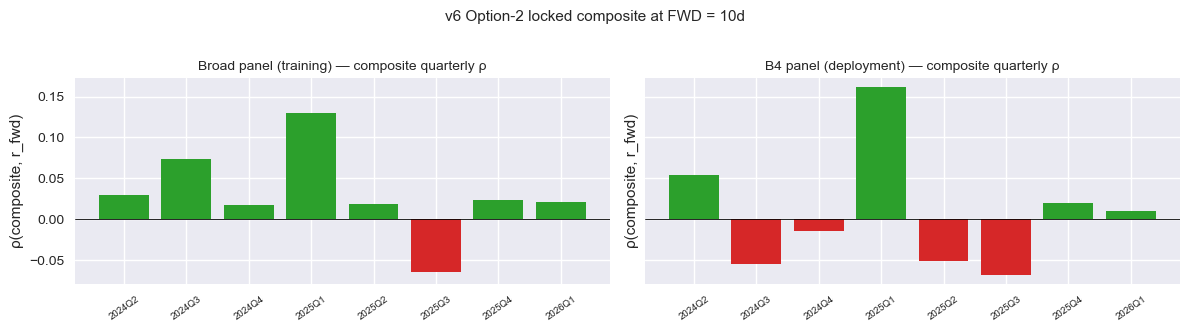


[v6-opt2] Exported: v6_opt2_summary, v6_opt2_broad_panel, v6_opt2_b4_panel, v6_opt2_verdict


In [9]:
# --- Bucket 4 v6 Option 2: locked 2-feature composite at 10d horizon -----
# Preconditions: cell 28 executed (provides closes_broad, feat_ts_broad in globals).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "closes_broad" in globals(), "Run cell 28 first (provides closes_broad)."
assert "_robust_z" in globals()

HORIZON_D       = 10
REBAL_EVERY_D   = 5       # sample every 5 days (signal is 10d fwd; we allow overlap here)
BT_LOOKBACK_D   = 504
TSTAT_THRESHOLD = 2.0
SIGN_FRAC_MIN   = 0.75
MIN_OBS_PER_Q   = 20

# LOCKED composite — two survivors from cell 28 broad-panel 10d screen.
LOCKED = [("r_10d", -1), ("range_expansion", +1)]
print(f"[v6-opt2] LOCKED composite @ {HORIZON_D}d: "
      f"{[(f, '+' if s>0 else '-') for f, s in LOCKED]}")

pd.set_option("display.width", 220)

# =========================================================================
# 1. Rebuild feature series from closes_broad (self-contained; don't rely on
#    cell 28's feat_ts_broad dict being in scope).
# =========================================================================
def _price_features(c: pd.Series) -> pd.DataFrame:
    c = c.astype(float)
    logret  = np.log(c / c.shift(1))
    sigma5  = logret.rolling(5,  min_periods=5).std(ddof=1)
    sigma63 = logret.rolling(63, min_periods=30).std(ddof=1)
    df = pd.DataFrame(index=c.index)
    df["r_10d"]           = np.log(c / c.shift(10))
    df["range_expansion"] = sigma5 / sigma63
    return df

feats = {u: _price_features(closes_broad[u]) for u in closes_broad.columns}

b4_live_names = sorted(set(b4["Underlying"]) & set(closes_broad.columns))
broad_live_names = list(closes_broad.columns)
print(f"[v6-opt2] broad_live={len(broad_live_names)}  b4_live={len(b4_live_names)}")

# =========================================================================
# 2. Panel builder (cross-sectional robust-z within given universe, per date).
# =========================================================================
def _build_panel(universe: list[str], horizon_d: int) -> pd.DataFrame:
    all_dates = closes_broad.index
    rebal_dates = all_dates[-BT_LOOKBACK_D::REBAL_EVERY_D]
    rebal_dates = [d for d in rebal_dates if d <= all_dates[-horizon_d - 1]]

    rows = []
    for as_of in rebal_dates:
        # Gather today's raw values per universe member.
        vals = {"r_10d": {}, "range_expansion": {}, "px0": {}, "px1": {}}
        for u in universe:
            ts = feats.get(u)
            if ts is None or as_of not in ts.index:
                continue
            if pd.notna(ts.at[as_of, "r_10d"]):
                vals["r_10d"][u] = float(ts.at[as_of, "r_10d"])
            if pd.notna(ts.at[as_of, "range_expansion"]):
                vals["range_expansion"][u] = float(ts.at[as_of, "range_expansion"])
            px = closes_broad[u]
            try:
                idx_now = px.index.get_loc(as_of)
            except KeyError:
                continue
            if idx_now + horizon_d >= len(px):
                continue
            p0, p1 = px.iat[idx_now], px.iat[idx_now + horizon_d]
            if np.isfinite(p0) and np.isfinite(p1) and p0 > 0 and p1 > 0:
                vals["px0"][u] = float(p0); vals["px1"][u] = float(p1)

        if len(vals["r_10d"]) < 5 or len(vals["range_expansion"]) < 5:
            continue

        z_r10  = _robust_z(pd.Series(vals["r_10d"]))
        z_rexp = _robust_z(pd.Series(vals["range_expansion"]))

        for u in universe:
            if u not in vals["px0"]:
                continue
            ar10  = -1 * z_r10.get(u, np.nan)
            arexp = +1 * z_rexp.get(u, np.nan)
            if not (np.isfinite(ar10) and np.isfinite(arexp)):
                continue
            comp = 0.5 * ar10 + 0.5 * arexp
            rows.append({
                "date": as_of, "Underlying": u,
                "r_fwd": np.log(vals["px1"][u] / vals["px0"][u]),
                "z_r10d":  float(-z_r10.get(u, np.nan)),
                "z_rexp":  float( z_rexp.get(u, np.nan)),
                "z_composite": float(comp),
            })
    p = pd.DataFrame(rows)
    if not p.empty:
        p["quarter"] = pd.PeriodIndex(p["date"], freq="Q")
    return p

# =========================================================================
# 3. Diagnostic helpers.
# =========================================================================
def _pearson_tstat(x: pd.Series, y: pd.Series) -> tuple[float, float, int]:
    df = pd.concat([x, y], axis=1).dropna()
    n = len(df)
    if n < 30:
        return (np.nan, np.nan, n)
    a = df.iloc[:, 0].values; b = df.iloc[:, 1].values
    rho = float(np.corrcoef(a, b)[0, 1])
    if not np.isfinite(rho) or abs(rho) >= 1.0:
        return (rho, np.nan, n)
    t = rho * np.sqrt(n - 2) / np.sqrt(1 - rho ** 2)
    return (rho, float(t), n)

def _quarterly_stats(panel: pd.DataFrame, col: str) -> tuple[int, int, float, list]:
    rho_pool, _, _ = _pearson_tstat(panel[col], panel["r_fwd"])
    if not np.isfinite(rho_pool):
        return (0, 0, np.nan, [])
    same = 0; nq = 0; details = []
    for q, sub in panel.groupby("quarter"):
        if len(sub) < MIN_OBS_PER_Q:
            continue
        rq, tq, nobs = _pearson_tstat(sub[col], sub["r_fwd"])
        if np.isfinite(rq):
            nq += 1
            if np.sign(rq) == np.sign(rho_pool):
                same += 1
            details.append({"q": str(q), "rho": rq, "t": tq, "n": nobs})
    return (same, nq, same / nq if nq > 0 else np.nan, details)

# =========================================================================
# 4. Step 1 — broad panel (training).
# =========================================================================
broad_panel = _build_panel(broad_live_names, HORIZON_D)
b4_panel    = _build_panel(b4_live_names,    HORIZON_D)

print(f"\n[v6-opt2] broad panel: {len(broad_panel)} obs  "
      f"({broad_panel['Underlying'].nunique()} underlyings × "
      f"{broad_panel['date'].nunique()} dates × {broad_panel['quarter'].nunique()} quarters)")
print(f"[v6-opt2] B4 panel:    {len(b4_panel)} obs  "
      f"({b4_panel['Underlying'].nunique()} underlyings × "
      f"{b4_panel['date'].nunique()} dates × {b4_panel['quarter'].nunique()} quarters)")

broad_results = {}
for col in ("z_r10d", "z_rexp", "z_composite"):
    rho, t, n = _pearson_tstat(broad_panel[col], broad_panel["r_fwd"])
    same, nq, frac, details = _quarterly_stats(broad_panel, col)
    broad_results[col] = {"rho": rho, "t": t, "N": n,
                          "same": same, "nq": nq, "frac": frac, "q": details}

b4_results = {}
for col in ("z_r10d", "z_rexp", "z_composite"):
    rho, t, n = _pearson_tstat(b4_panel[col], b4_panel["r_fwd"])
    same, nq, frac, details = _quarterly_stats(b4_panel, col)
    b4_results[col] = {"rho": rho, "t": t, "N": n,
                       "same": same, "nq": nq, "frac": frac, "q": details}

# =========================================================================
# 5. Summary table.
# =========================================================================
rows = []
for col, label in [("z_r10d","−z(r_10d) (component)"),
                   ("z_rexp","+z(range_expansion) (component)"),
                   ("z_composite","COMPOSITE ½ + ½")]:
    br = broad_results[col]; b4r = b4_results[col]
    rows.append({
        "signal":       label,
        "broad_rho":    br["rho"],
        "broad_t":      br["t"],
        "broad_N":      br["N"],
        "broad_stable": f"{br['same']}/{br['nq']} ({br['frac']:.0%})",
        "b4_rho":       b4r["rho"],
        "b4_t":         b4r["t"],
        "b4_N":         b4r["N"],
        "b4_stable":    f"{b4r['same']}/{b4r['nq']} ({b4r['frac']:.0%})",
    })
summary = pd.DataFrame(rows)
disp = summary.copy()
for c in ("broad_rho","broad_t","b4_rho","b4_t"):
    disp[c] = disp[c].round(4 if "rho" in c else 2)
print("\n=== v6-opt2 summary ===\n")
print(disp.to_string(index=False))

# =========================================================================
# 6. Pre-registered decision rules.
# =========================================================================
br = broad_results["z_composite"]
b4r = b4_results["z_composite"]

broad_pass = (np.isfinite(br["t"]) and abs(br["t"]) >= TSTAT_THRESHOLD
              and np.isfinite(br["frac"]) and br["frac"] >= SIGN_FRAC_MIN)
sign_consistent = (np.isfinite(br["rho"]) and np.isfinite(b4r["rho"])
                   and np.sign(br["rho"]) == np.sign(b4r["rho"]))
effect_preserved = (np.isfinite(br["rho"]) and np.isfinite(b4r["rho"])
                    and abs(b4r["rho"]) >= 0.5 * abs(br["rho"]))

print("\n=== Pre-registered decision ===")
print(f"  Broad panel: ρ={br['rho']:+.4f}, t={br['t']:+.2f}, stability={br['same']}/{br['nq']} ({br['frac']:.0%})")
print(f"  B4 panel:    ρ={b4r['rho']:+.4f}, t={b4r['t']:+.2f}, stability={b4r['same']}/{b4r['nq']} ({b4r['frac']:.0%})")
print(f"  (1) Broad passes |t|≥{TSTAT_THRESHOLD} AND stability≥{SIGN_FRAC_MIN:.0%}: "
      f"{'PASS' if broad_pass else 'FAIL'}")
print(f"  (2) B4 sign matches broad:                                 "
      f"{'PASS' if sign_consistent else 'FAIL'}")
print(f"  (3) B4 |ρ| ≥ 50% of broad |ρ|:                              "
      f"{'PASS' if effect_preserved else 'FAIL'}")

if broad_pass and sign_consistent and effect_preserved:
    verdict = "DEPLOY_CANDIDATE"
    msg = ("Composite clears all three bars. Proceed to v6 production wiring: "
           f"h_i = clip(0.5 − K · z_composite, H_MIN, H_MAX) with K ≈ 0.05 and EMA α = 0.25. "
           f"Rebalance every {HORIZON_D} trading days.")
elif broad_pass and not (sign_consistent and effect_preserved):
    verdict = "RESEARCH_ONLY"
    msg = ("Composite passes on broad but fails on B4 (sign flip or effect collapse). "
           "Keep as diagnostic column only; do NOT deploy.")
else:
    verdict = "KILL"
    msg = ("Composite fails broad-panel test. Ship static h = 0.5 with high confidence "
           "and close the simple-feature hedge-ratio research line.")

print(f"\n>>> VERDICT: {verdict}")
print(f"    {msg}")

# =========================================================================
# 7. Economic significance estimate.
# =========================================================================
if np.isfinite(br["rho"]) and np.isfinite(b4r["rho"]):
    rho_for_econ = b4r["rho"] if sign_consistent else br["rho"]
    sigma_und_ann_mean = float(np.sqrt(252) * np.log(closes_broad[b4_live_names]).diff().std().mean())
    sigma_h = sigma_und_ann_mean * np.sqrt(HORIZON_D / 252.0)
    h_tilt_range = 0.10
    beta_abs = 2.0
    alpha_per_rebal = h_tilt_range * abs(rho_for_econ) * sigma_h * beta_abs
    alpha_annual = alpha_per_rebal * (252.0 / HORIZON_D)
    print("\n=== Economic significance (rough) ===")
    print(f"  σ_und (ann, mean over B4): {sigma_und_ann_mean:.2%}")
    print(f"  σ_und over {HORIZON_D}d:           {sigma_h:.2%}")
    print(f"  Effective |ρ|:             {abs(rho_for_econ):.4f}")
    print(f"  Alpha per rebalance:       {alpha_per_rebal:.4%}  (gross)")
    print(f"  Annualized hedge alpha:    {alpha_annual:.2%}  (gross, B4 leg)")
    print(f"  → On 25% sleeve:           {alpha_annual * 0.25:.3%}  /yr to total book")

# =========================================================================
# 8. Quarterly rho bar chart for the composite.
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for ax, (label, details) in zip(
    axes, [("Broad panel (training)", broad_results["z_composite"]["q"]),
           ("B4 panel (deployment)",   b4_results["z_composite"]["q"])]
):
    if details:
        qs = [d["q"] for d in details]
        rs = [d["rho"] for d in details]
        colors = ["#2ca02c" if r >= 0 else "#d62728" for r in rs]
        ax.bar(qs, rs, color=colors)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(f"{label} — composite quarterly ρ", fontsize=10)
        ax.set_ylabel("ρ(composite, r_fwd)")
        ax.tick_params(axis="x", labelrotation=35, labelsize=7)
fig.suptitle(f"v6 Option-2 locked composite at FWD = {HORIZON_D}d", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

globals()["v6_opt2_summary"]      = summary
globals()["v6_opt2_broad_panel"]  = broad_panel
globals()["v6_opt2_b4_panel"]     = b4_panel
globals()["v6_opt2_verdict"]      = verdict
print("\n[v6-opt2] Exported: v6_opt2_summary, v6_opt2_broad_panel, v6_opt2_b4_panel, v6_opt2_verdict")

In [10]:
# --- Bucket 4 v6 Option-2: per-pair backtest (locked r_10d + range_expansion, B4 cross-section, 10d rebalance) ---
# Run after: v6-ext (`closes_broad`), v6 feature-bank (`_robust_z`), Bucket-4 sweep (pairs, `load_prices`, params).
import numpy as np
import pandas as pd

assert "closes_broad" in globals(), "Run v6-ext (closes_broad) first."
assert "_robust_z" in globals(), "Run v6 feature-bank for _robust_z."
assert "BUCKET4_PAIRS" in globals() and BUCKET4_PAIRS, "Run Bucket-4 sweep (BUCKET4_PAIRS)."

V6_OPT2_K = 0.05
V6_OPT2_ALPHA = 0.25
V6_H_MIN = 0.10
V6_H_MAX = 1.10
V6_BDAY_STEP = 10
WARMUP_BDAYS = 65
MIN_XSEC = 5

def _opt2_price_features(c: pd.Series) -> pd.DataFrame:
    c = c.astype(float)
    logret = np.log(c / c.shift(1))
    sigma5 = logret.rolling(5, min_periods=5).std(ddof=1)
    sigma63 = logret.rolling(63, min_periods=30).std(ddof=1)
    out = pd.DataFrame(index=c.index)
    out["r_10d"] = np.log(c / c.shift(10))
    out["range_expansion"] = sigma5 / sigma63
    return out

def _panel_to_h_daily_b4(
    panel: pd.DataFrame, master_index: pd.DatetimeIndex, underlyings: list[str]
) -> dict[str, pd.Series]:
    if panel is None or panel.empty:
        return {u: pd.Series(0.5, index=master_index) for u in underlyings}
    pivot = panel.pivot_table(index="date", columns="underlying", values="h_applied", aggfunc="last")
    out: dict[str, pd.Series] = {}
    for u in underlyings:
        s = (
            pivot[u].reindex(master_index).ffill()
            if u in pivot.columns
            else pd.Series(np.nan, index=master_index)
        )
        out[u] = s.fillna(0.5)
    return out

def _build_h_panel_opt2_b4() -> tuple[pd.DataFrame, pd.DatetimeIndex, list[str]]:
    all_dates = closes_broad.index.sort_values()
    b4_unds = sorted({u for _, u in BUCKET4_PAIRS} & set(closes_broad.columns))
    if not b4_unds:
        raise RuntimeError("No B4 underlyings intersect closes_broad.")
    feats = {u: _opt2_price_features(closes_broad[u]) for u in b4_unds}
    rebal = all_dates[WARMUP_BDAYS::V6_BDAY_STEP]
    h_prev = {u: 0.5 for u in b4_unds}
    rows: list[dict] = []
    for as_of in rebal:
        v10, vrx = {}, {}
        for u, ts in feats.items():
            if as_of not in ts.index:
                continue
            t10, trx = ts.at[as_of, "r_10d"], ts.at[as_of, "range_expansion"]
            if pd.notna(t10):
                v10[u] = float(t10)
            if pd.notna(trx):
                vrx[u] = float(trx)
        if len(v10) < MIN_XSEC or len(vrx) < MIN_XSEC:
            for u in b4_unds:
                rows.append(
                    {
                        "date": as_of,
                        "underlying": u,
                        "z_composite": np.nan,
                        "h_applied": h_prev[u],
                    }
                )
            continue
        z10 = _robust_z(pd.Series(v10))
        zrx = _robust_z(pd.Series(vrx))
        for u in b4_unds:
            a_raw = -1.0 * z10.get(u, np.nan)
            b_raw = +1.0 * zrx.get(u, np.nan)
            zc = np.nan
            if pd.isna(a_raw) and pd.isna(b_raw):
                h_new = h_prev[u]
            else:
                a = 0.0 if pd.isna(a_raw) else float(a_raw)
                b = 0.0 if pd.isna(b_raw) else float(b_raw)
                zc = 0.5 * a + 0.5 * b
                h_star = float(np.clip(0.5 - V6_OPT2_K * zc, V6_H_MIN, V6_H_MAX))
                h_new = (1.0 - V6_OPT2_ALPHA) * h_prev[u] + V6_OPT2_ALPHA * h_star
                h_prev[u] = h_new
            rows.append(
                {
                    "date": as_of,
                    "underlying": u,
                    "z_composite": zc,
                    "h_applied": h_new,
                }
            )
    return pd.DataFrame(rows), rebal, b4_unds


def run_bucket4_backtest_dynamic_h(
    prices: pd.DataFrame,
    h_daily: pd.Series,
    rebal_dates: pd.DatetimeIndex,
    *,
    initial_capital: float = 100_000.0,
    gross_multiplier: float = 1.0,
    beta_a: float = -2.0,
    beta_b: float = 1.0,
    borrow_a_annual: float = 0.0,
    borrow_b_annual: float = 0.0,
    short_proceeds_annual: float = 0.0,
    fee_bps: float = 0.0,
) -> pd.DataFrame:
    bt = prices.copy()
    h_aligned = h_daily.reindex(bt.index).ffill().fillna(0.5)
    bt["rebalance"] = bt.index.isin(rebal_dates)
    bt.iloc[0, bt.columns.get_loc("rebalance")] = True

    a_sh, b_sh = 0.0, 0.0
    cash = float(initial_capital)
    fee_rate = fee_bps / 10_000.0
    borrow_a_daily = float(borrow_a_annual) / 252.0
    borrow_b_daily = float(borrow_b_annual) / 252.0
    short_proceeds_daily = float(short_proceeds_annual) / 252.0
    beta_inv_abs = abs(float(beta_a))

    rows: list[dict] = []
    for dt, row in bt.iterrows():
        ap = float(row["a_px"])
        bp = float(row["b_px"])
        h = float(h_aligned.loc[dt])
        a_pos_notional = a_sh * ap
        b_pos_notional = b_sh * bp
        borrow_cost = 0.0
        short_proceeds_credit = 0.0
        if a_pos_notional < 0:
            borrow_cost += abs(a_pos_notional) * borrow_a_daily
            short_proceeds_credit += abs(a_pos_notional) * short_proceeds_daily
        if b_pos_notional < 0:
            borrow_cost += abs(b_pos_notional) * borrow_b_daily
            short_proceeds_credit += abs(b_pos_notional) * short_proceeds_daily
        financing_pnl = short_proceeds_credit - borrow_cost
        cash += financing_pnl
        equity = cash + a_pos_notional + b_pos_notional

        if bool(row["rebalance"]):
            target_gross = max(0.0, float(gross_multiplier) * equity)
            denom = 1.0 + h * beta_inv_abs
            n_a = target_gross / denom if denom > 1e-12 else 0.5 * target_gross
            n_b = max(0.0, target_gross - n_a)
            target_a_pos, target_b_pos = -n_a, -n_b
            delta_a, delta_b = target_a_pos - a_pos_notional, target_b_pos - b_pos_notional
            fee = (abs(delta_a) + abs(delta_b)) * fee_rate
            cash -= delta_a + delta_b + fee
            a_sh = target_a_pos / ap if ap > 0 else 0.0
            b_sh = target_b_pos / bp if bp > 0 else 0.0
            a_pos_notional, b_pos_notional = a_sh * ap, b_sh * bp
            equity = cash + a_pos_notional + b_pos_notional

        beta_notional = (
            (-1.0) * float(beta_a) * abs(a_pos_notional) + (-1.0) * float(beta_b) * abs(b_pos_notional)
        )
        rows.append(
            {
                "date": dt,
                "a_px": ap,
                "b_px": bp,
                "cash": cash,
                "a_shares": a_sh,
                "b_shares": b_sh,
                "equity": equity,
                "h_used": h,
                "rebalance": bool(row["rebalance"]),
                "beta_notional": beta_notional,
                "borrow_cost": borrow_cost,
                "short_proceeds_credit": short_proceeds_credit,
                "financing_pnl": financing_pnl,
            }
        )
    out = pd.DataFrame(rows).set_index("date")
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["drawdown"] = out["equity"].div(out["equity"].cummax()).sub(1.0)
    out["beta_exposure_frac"] = np.where(
        out["equity"].abs() > 1e-9, out["beta_notional"] / out["equity"], np.nan
    )
    return out

h_panel_b4, v6_opt2_rebal_index, b4_unds_list = _build_h_panel_opt2_b4()
all_idx = closes_broad.index.sort_values()
h_daily_map = _panel_to_h_daily_b4(h_panel_b4, all_idx, b4_unds_list)

v6_opt2_h_panel_b4 = h_panel_b4
print(
    f"[v6-opt2 backtest] B4 underlyings={len(b4_unds_list)}  h-panel rows={len(h_panel_b4)}  "
    f"rebal dates={len(v6_opt2_rebal_index)} (every {V6_BDAY_STEP} bdays, K={V6_OPT2_K}, α={V6_OPT2_ALPHA})"
)

if "underlying_ibkr_map" not in globals():
    underlying_ibkr_map = {}
if "BETA_SOURCE_CSV" not in globals() or "BORROW_SOURCE_GLOBS" not in globals():
    raise RuntimeError("Run Parameters / Bucket-4 cell so BETA_SOURCE_CSV, BORROW… exist.")

v6_opt2_backtest_rows: list[dict] = []
for etf_sym, und_sym in BUCKET4_PAIRS:
    if und_sym not in b4_unds_list:
        print(f"[SKIP] {etf_sym}/{und_sym} — underlying not in v6 B4/price panel")
        continue
    try:
        prices_i = load_prices(etf_sym, und_sym, START, END)
    except Exception as e:
        print(f"[SKIP] {etf_sym}/{und_sym} — {e}")
        continue
    if prices_i is None or prices_i.empty:
        continue
    h_d = h_daily_map[und_sym].reindex(prices_i.index).ffill().fillna(0.5)
    pair_rebal = v6_opt2_rebal_index.intersection(prices_i.index)
    if len(pair_rebal) == 0:
        pair_rebal = pd.DatetimeIndex([prices_i.index[0]])

    beta_a_i, beta_b_i = load_beta_values(
        etf_sym,
        und_sym,
        BETA_SOURCE_CSV,
        USE_BETA_FROM_SCREENED,
        LEG_A_BETA,
        LEG_B_BETA,
    )
    if (etf_sym, und_sym) == ("UVIX", "SVIX"):
        beta_a_i, beta_b_i = 2.0, -1.0
    elif beta_a_i >= 0:
        print(f"[SKIP] {etf_sym}/{und_sym} — non-inverse beta_a")
        continue
    borrow_a_i, _ = load_pair_borrow_rates(
        etf_sym,
        und_sym,
        BORROW_SOURCE_GLOBS,
        USE_BORROW_FROM_SCREENED,
        BORROW_FALLBACK_ANNUAL,
        underlying_ibkr_map=underlying_ibkr_map,
        manual_override=MANUAL_BORROW_OVERRIDE,
    )
    borrow_b_i = float(UNDERLYING_INTERNALIZED_BORROW_ANNUAL)

    bt_v6 = run_bucket4_backtest_dynamic_h(
        prices_i,
        h_d,
        pair_rebal,
        initial_capital=INITIAL_CAPITAL,
        gross_multiplier=TARGET_GROSS_MULTIPLIER,
        beta_a=beta_a_i,
        beta_b=beta_b_i,
        borrow_a_annual=borrow_a_i,
        borrow_b_annual=borrow_b_i,
        short_proceeds_annual=SHORT_PROCEEDS_ANNUAL,
        fee_bps=FEE_BPS,
    )
    st = perf_stats(bt_v6)
    bfrac = float(bt_v6["beta_exposure_frac"].dropna().mean())
    havg = float(bt_v6["h_used"].mean())
    v6_opt2_backtest_rows.append(
        {
            "pair": f"{etf_sym}/{und_sym}",
            "run": "v6_opt2_dynamic",
            "cagr": float(st.get("CAGR", np.nan)),
            "total_return": float(st.get("Total Return", np.nan)),
            "max_drawdown": float(st.get("Max Drawdown", np.nan)),
            "sharpe": float(st.get("Sharpe", np.nan)),
            "avg_h": havg,
            "avg_beta_exposure_frac": bfrac,
        }
    )

v6_opt2_pair_backtest_df = pd.DataFrame(v6_opt2_backtest_rows)
if v6_opt2_pair_backtest_df.empty:
    raise RuntimeError("No v6 Option-2 backtest rows; check data / skips.")
print("\n=== v6 Option-2 per-pair backtest (dynamic h) ===")
print(v6_opt2_pair_backtest_df.sort_values("cagr", ascending=False).to_string(index=False))
globals()["v6_opt2_h_panel_b4"] = v6_opt2_h_panel_b4
globals()["v6_opt2_rebal_index"] = v6_opt2_rebal_index
globals()["v6_opt2_h_daily_map"] = h_daily_map
globals()["v6_opt2_pair_backtest_df"] = v6_opt2_pair_backtest_df
print("\n[v6-opt2] Exported: v6_opt2_h_panel_b4, v6_opt2_rebal_index, v6_opt2_h_daily_map, v6_opt2_pair_backtest_df")

[v6-opt2 backtest] B4 underlyings=8  h-panel rows=1360  rebal dates=170 (every 10 bdays, K=0.05, α=0.25)
[PAIR START] MSTZ/MSTR aligned start moved from 2022-03-31 to 2024-09-18
[PAIR START] CONI/COIN aligned start moved from 2022-03-31 to 2024-09-04
[PAIR START] MSDD/MSTR aligned start moved from 2022-03-31 to 2025-06-10
[SKIP] ETHD/ETHA — underlying not in v6 B4/price panel
[SKIP] CRCD/CRCL — underlying not in v6 B4/price panel
[SKIP] CORD/CRWV — underlying not in v6 B4/price panel
[PAIR START] APLZ/APLD aligned start moved from 2022-03-31 to 2026-01-22
[PAIR START] BEZ/BE aligned start moved from 2022-03-31 to 2026-02-11
[SKIP] NBIZ/NBIS — underlying not in v6 B4/price panel
[PAIR START] SMZ/SMR aligned start moved from 2022-03-31 to 2026-02-11
[PAIR START] CLSZ/CLSK aligned start moved from 2022-03-31 to 2026-02-19
[PAIR START] IREZ/IREN aligned start moved from 2022-03-31 to 2026-01-22

=== v6 Option-2 per-pair backtest (dynamic h) ===
     pair             run      cagr  total_re

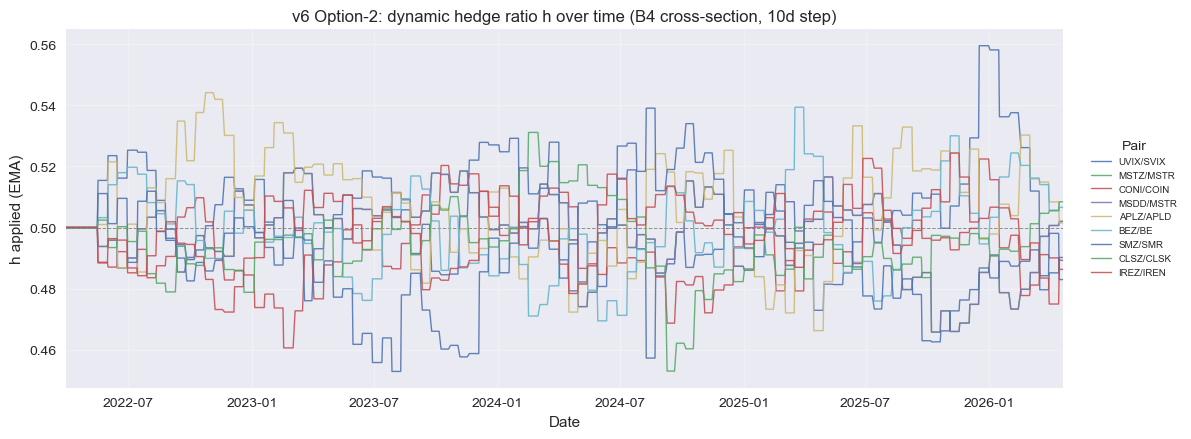

In [11]:
# Plot v6 Option-2 applied hedge h over time (one line per pair; h is keyed by underlying)
import matplotlib.pyplot as plt
import pandas as pd

assert "v6_opt2_h_daily_map" in globals() and "BUCKET4_PAIRS" in globals(), (
    "Run the v6 Option-2 per-pair backtest cell first (exports v6_opt2_h_daily_map)."
)

hmap = v6_opt2_h_daily_map
plotted: list[pd.Series] = []
fig, ax = plt.subplots(figsize=(12, 4.5))
for etf, und in BUCKET4_PAIRS:
    if und not in hmap:
        continue
    s = hmap[und]
    if s is None or s.dropna().empty:
        continue
    ax.plot(s.index, s.values, label=f"{etf}/{und}", alpha=0.88, linewidth=1.0)
    plotted.append(s)
if not plotted:
    raise RuntimeError("No h series to plot — check v6 opt2 backtest and B4 panel.")
tmax = max(ser.index.max() for ser in plotted)
tmin = min(ser.index.min() for ser in plotted)
left = pd.Timestamp(START) if "START" in globals() and START is not None else tmin
right = pd.Timestamp(END) if "END" in globals() and END is not None else tmax
if right < left:
    left, right = tmin, tmax
ax.set_xlim(left=left, right=right)
ax.set_ylabel("h applied (EMA)")
ax.set_xlabel("Date")
ax.set_title("v6 Option-2: dynamic hedge ratio h over time (B4 cross-section, 10d step)")
ax.axhline(0.5, color="0.4", ls="--", lw=0.7, zorder=0)
ax.grid(True, alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, title="Pair", framealpha=0.9)
fig.tight_layout()
plt.show()